# Ensembl × CAT Annotation Exploration

Where and how do the two annotation strategies agree and disagree across the HPRC pangenome?

| Source | Rows | Key columns |
|--------|------|-------------|
| `S1` (local) | 40K genes | presence, transcript concordance, biotype |
| `divergence.parquet` | 18.5M | per-assembly CDS change type vs GRCh38, structural deltas |
| `coding_integrity.parquet` | 8.6M | per-assembly Ensembl vs CAT CDS agreement |
| mygene.info (cached) | — | GRCh38 chromosome coordinates per gene |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings, time
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA  = Path('../../../../data/supplementary_tables')
CACHE = DATA / 'cache'
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Consistent colour palette across all plots
DIV_PALETTE = {
    'both_agree_reference':        '#2ca02c',
    'both_agree_diverged':         '#98df8a',
    'cat_specific_divergence':     '#d62728',
    'ensembl_specific_divergence': '#ff7f0e',
    'insufficient_data':           '#aec7e8',
}
DIV_ORDER = list(DIV_PALETTE)
CHROM_ORDER = [str(i) for i in range(1, 23)] + ['X', 'Y', 'MT']

def safe_mode(series):
    m = series.dropna().mode()
    return m.iloc[0] if len(m) > 0 else np.nan

print('Setup done.')

Setup done.


## 1. Load data

In [2]:
t0 = time.time()
s1_raw = pd.read_csv(DATA / 'supp_table_s1_gene_concordance_summary.tsv', sep='\t')
print(f'S1: {len(s1_raw):,} genes × {s1_raw.shape[1]} cols  ({time.time()-t0:.1f}s)')

# Load a slim version of divergence — only the columns we need
t0 = time.time()
div_cols = [
    'assembly_accession', 'gene_name', 'ensembl_biotype', 'is_coding',
    'ens_cds_match', 'cat_cds_match',
    'ens_cds_change_type', 'cat_cds_change_type',
    'ens_delta_n_exons', 'cat_delta_n_exons',
    'ens_delta_cds_length', 'cat_delta_cds_length',
    'ens_diverged', 'cat_diverged',
    'divergence_category',
]
div = pd.read_parquet(CACHE / 'divergence.parquet', columns=div_cols)
div['ens_cds_match'] = div['ens_cds_match'].map({True: 1.0, False: 0.0})
div['cat_cds_match'] = div['cat_cds_match'].map({True: 1.0, False: 0.0})
# Downcast string columns to Categorical (~2–3 GB saved on 18.5 M rows)
for _col in ['divergence_category', 'ens_cds_change_type', 'cat_cds_change_type', 'ensembl_biotype']:
    if _col in div.columns:
        div[_col] = div[_col].astype('category')
# Downcast numeric delta columns float64 → float32
div['ens_delta_n_exons']    = div['ens_delta_n_exons'].astype('float32')
div['cat_delta_n_exons']    = div['cat_delta_n_exons'].astype('float32')
div['ens_delta_cds_length'] = div['ens_delta_cds_length'].astype('float32')
div['cat_delta_cds_length'] = div['cat_delta_cds_length'].astype('float32')
print(f'divergence: {len(div):,} rows  ({time.time()-t0:.1f}s)')


S1: 40,824 genes × 27 cols  (0.1s)
divergence: 18,562,662 rows  (6.4s)


## 2. Build per-gene enriched summary

Compute reference-anchored metrics directly from `divergence.parquet`.  
This makes the notebook self-contained and doesn't depend on the HPC-generated S1 having the latest columns.

In [3]:
t0 = time.time()

# ── Divergence category pcts per canonical gene ──
div_base = div.dropna(subset=['gene_name', 'divergence_category'])
div_counts = (div_base.groupby(['gene_name', 'divergence_category'])
              .size().unstack(fill_value=0).reset_index())
for cat in DIV_ORDER:
    if cat not in div_counts.columns:
        div_counts[cat] = 0
div_counts['_n'] = div_counts[DIV_ORDER].sum(axis=1)
for cat in DIV_ORDER:
    div_counts[f'pct_{cat}'] = np.where(
        div_counts['_n'] > 0, (div_counts[cat] / div_counts['_n'] * 100).round(1), np.nan)
div_mode = (div_base.groupby('gene_name')['divergence_category']
            .agg(safe_mode).reset_index()
            .rename(columns={'divergence_category': 'predominant_divergence_category'}))
pct_div_cols = [f'pct_{cat}' for cat in DIV_ORDER]
gene_div = div_counts[['gene_name'] + pct_div_cols].merge(div_mode, on='gene_name', how='left')
print(f'gene_div: {len(gene_div):,} genes  ({time.time()-t0:.1f}s)')

# ── Reference-anchored CDS quality (coding genes only) ──
div_coding = div[div['is_coding'] == True].dropna(subset=['gene_name']).copy()

div_coding['ens_coding_lost']    = div_coding['ens_cds_change_type'] == 'coding_lost'
div_coding['cat_coding_lost']    = div_coding['cat_cds_change_type'] == 'coding_lost'
div_coding['ens_frameshift_ref'] = div_coding['ens_cds_change_type'].isin(
    ['frameshift_shorter', 'frameshift_longer'])
div_coding['cat_frameshift_ref'] = div_coding['cat_cds_change_type'].isin(
    ['frameshift_shorter', 'frameshift_longer'])

# Use row count as denominator (gene_name is always non-null here after dropna above)
# This avoids pct > 100 for IG genes where ens_cds_match is NaN but cat events exist
ref_cds = div_coding.groupby('gene_name').agg(
    _n=('gene_name', 'count'),
    _sum_ens_cds=('ens_cds_match', 'sum'),
    _sum_cat_cds=('cat_cds_match', 'sum'),
    _sum_ens_cl=('ens_coding_lost', 'sum'),
    _sum_cat_cl=('cat_coding_lost', 'sum'),
    _sum_ens_fs=('ens_frameshift_ref', 'sum'),
    _sum_cat_fs=('cat_frameshift_ref', 'sum'),
).reset_index()
for col, s in [
    ('pct_ens_cds_match_ref',  '_sum_ens_cds'),
    ('pct_cat_cds_match_ref',  '_sum_cat_cds'),
    ('pct_ens_coding_lost',    '_sum_ens_cl'),
    ('pct_cat_coding_lost',    '_sum_cat_cl'),
    ('pct_ens_frameshift_ref', '_sum_ens_fs'),
    ('pct_cat_frameshift_ref', '_sum_cat_fs'),
]:
    ref_cds[col] = np.where(ref_cds['_n'] > 0,
                            (ref_cds[s] / ref_cds['_n'] * 100).round(1), np.nan)

ens_mode = (div_coding.dropna(subset=['ens_cds_change_type'])
            .groupby('gene_name')['ens_cds_change_type'].agg(safe_mode).reset_index()
            .rename(columns={'ens_cds_change_type': 'predominant_ens_cds_change_type'}))
cat_mode = (div_coding.dropna(subset=['cat_cds_change_type'])
            .groupby('gene_name')['cat_cds_change_type'].agg(safe_mode).reset_index()
            .rename(columns={'cat_cds_change_type': 'predominant_cat_cds_change_type'}))

ref_cds_cols = ['gene_name', 'pct_ens_cds_match_ref', 'pct_cat_cds_match_ref',
                'pct_ens_coding_lost', 'pct_cat_coding_lost',
                'pct_ens_frameshift_ref', 'pct_cat_frameshift_ref']
gene_ref_cds = (ref_cds[ref_cds_cols]
                .merge(ens_mode, on='gene_name', how='left')
                .merge(cat_mode, on='gene_name', how='left'))
print(f'gene_ref_cds: {len(gene_ref_cds):,} coding genes  ({time.time()-t0:.1f}s)')

# ── Biotype from divergence (most common per gene) ──
gene_biotype = (div.dropna(subset=['gene_name'])
                .groupby('gene_name')['ensembl_biotype'].agg(safe_mode)
                .reset_index().rename(columns={'ensembl_biotype': 'ensembl_biotype_div'}))

# ── Assemble enriched per-gene table ──
# Start from S1 for presence/concordance stats, add computed columns
_recomputed = (set(gene_div.columns) | set(gene_ref_cds.columns)) - {'gene_name'}
s1_base = s1_raw.drop(columns=[c for c in s1_raw.columns if c in _recomputed], errors='ignore')
s1 = (s1_base
      .merge(gene_div, on='gene_name', how='left')
      .merge(gene_ref_cds, on='gene_name', how='left')
      .merge(gene_biotype, on='gene_name', how='left'))

# Use freshly computed divergence columns (old ones had wrong category names)
print(f's1 enriched: {len(s1):,} genes × {s1.shape[1]} cols  ({time.time()-t0:.1f}s)')
print('divergence category sample:', s1['predominant_divergence_category'].value_counts().head())

gene_div: 40,821 genes  (8.2s)
gene_ref_cds: 19,655 coding genes  (15.3s)
s1 enriched: 40,824 genes × 28 cols  (20.8s)
divergence category sample: predominant_divergence_category
both_agree_reference           33767
both_agree_diverged             5915
cat_specific_divergence          620
insufficient_data                428
ensembl_specific_divergence       91
Name: count, dtype: int64


## 3. Chromosomal positions (mygene.info, cached)

In [4]:
chrom_cache = CACHE / 'gene_positions_grch38.parquet'

if chrom_cache.exists():
    gpos = pd.read_parquet(chrom_cache)
    print(f'Loaded from cache: {len(gpos):,} genes with positions')
else:
    import mygene
    mg = mygene.MyGeneInfo()
    gene_names = s1['gene_name'].dropna().unique().tolist()
    print(f'Querying mygene.info for {len(gene_names):,} gene symbols...')
    results = mg.querymany(gene_names, scopes='symbol', fields='genomic_pos',
                           species='human', returnall=False, verbose=False)
    rows = []
    for r in results:
        gp = r.get('genomic_pos')
        if gp is None:
            continue
        if isinstance(gp, dict):
            gp = [gp]
        for locus in gp:
            chrom = str(locus.get('chr', ''))
            if chrom not in [str(i) for i in range(1, 23)] + ['X', 'Y', 'MT']:
                continue
            rows.append({'gene_name': r['query'], 'chrom': chrom,
                         'start': locus.get('start'), 'end': locus.get('end'),
                         'strand': locus.get('strand')})
    gpos = (pd.DataFrame(rows).drop_duplicates('gene_name'))
    gpos['start'] = pd.to_numeric(gpos['start'], errors='coerce')
    gpos['end']   = pd.to_numeric(gpos['end'],   errors='coerce')
    gpos['midpoint'] = (gpos['start'] + gpos['end']) / 2  # float64, NaN-safe
    gpos.to_parquet(chrom_cache, index=False)
    print(f'Got positions for {len(gpos):,} / {len(gene_names):,} genes → cached')

gpos['chrom'] = pd.Categorical(gpos['chrom'], categories=CHROM_ORDER, ordered=True)
s1g = s1.merge(gpos[['gene_name', 'chrom', 'start', 'end', 'midpoint']], on='gene_name', how='left')
print(f's1g: {s1g["chrom"].notna().sum():,} / {len(s1g):,} genes have coordinates')

Loaded from cache: 40,494 genes with positions
s1g: 40,494 / 40,824 genes have coordinates


## 4. Concordance by chromosome — stacked bar

What fraction of named genes on each chromosome show each concordance pattern?

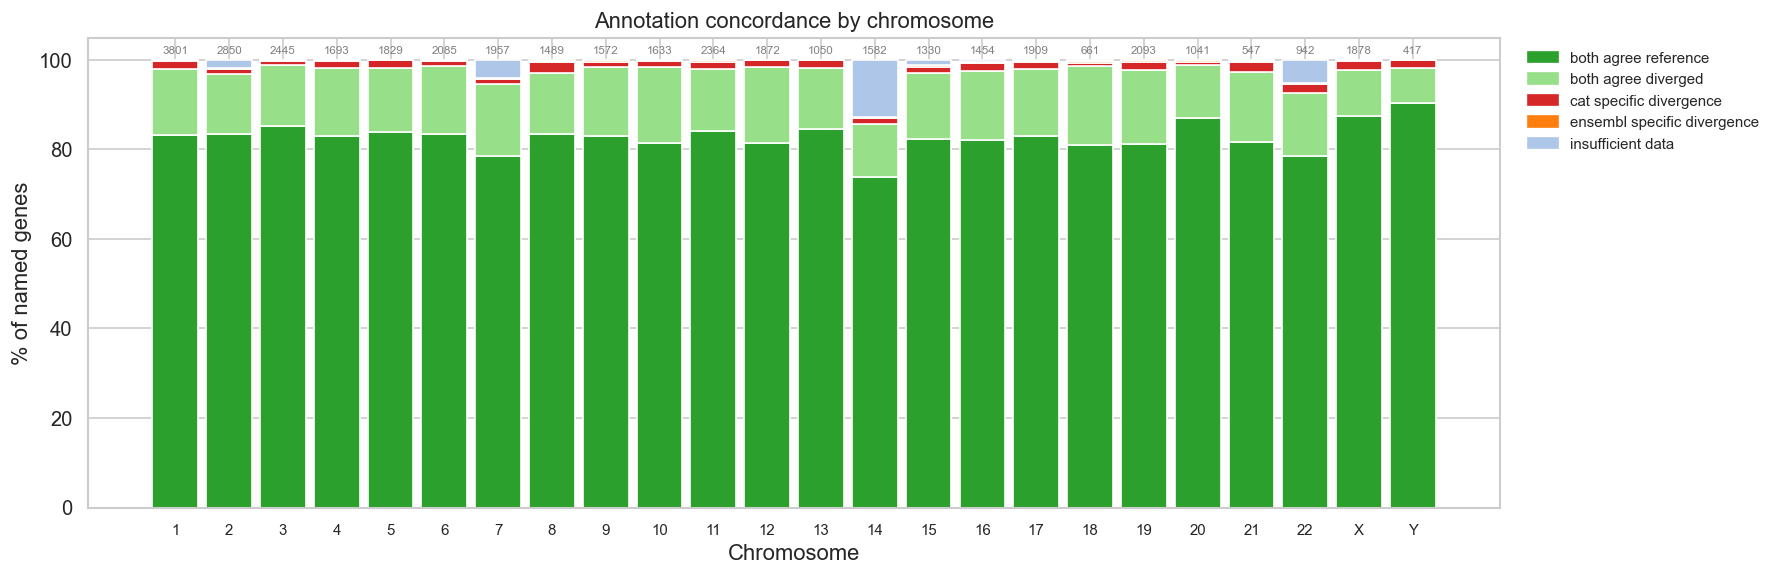

In [5]:
s1g_chr = s1g[s1g['chrom'].notna()].copy()
s1g_chr['chrom'] = s1g_chr['chrom'].astype(str)

pdc = (s1g_chr.groupby(['chrom', 'predominant_divergence_category'])
       .size().unstack(fill_value=0))
pdc = pdc.reindex([c for c in CHROM_ORDER if c in pdc.index])
pdc_pct = pdc.div(pdc.sum(axis=1), axis=0) * 100
plot_cats = [c for c in DIV_ORDER if c in pdc_pct.columns]
pdc_pct = pdc_pct[plot_cats]

fig, ax = plt.subplots(figsize=(15, 5))
bottom = np.zeros(len(pdc_pct))
for cat in plot_cats:
    vals = pdc_pct[cat].values
    ax.bar(range(len(pdc_pct)), vals, bottom=bottom,
           color=DIV_PALETTE[cat], label=cat.replace('_', ' '), width=0.85)
    bottom += vals

ax.set_xticks(range(len(pdc_pct)))
ax.set_xticklabels(pdc_pct.index, fontsize=9)
ax.set_xlabel('Chromosome')
ax.set_ylabel('% of named genes')
ax.set_title('Annotation concordance by chromosome')
ax.set_ylim(0, 105)
for i, (chrom, row) in enumerate(pdc.iterrows()):
    ax.text(i, 101, str(int(row.sum())), ha='center', va='bottom', fontsize=7, color='grey')

handles = [mpatches.Patch(color=DIV_PALETTE[c], label=c.replace('_', ' ')) for c in plot_cats]
ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'chrom_concordance_stacked.png', bbox_inches='tight')
plt.show()

## 5. Discordant gene density along chromosomal position

10 Mb bins. Green = all genes; red = CAT diverges (≥10%); orange = Ensembl diverges (≥10%).

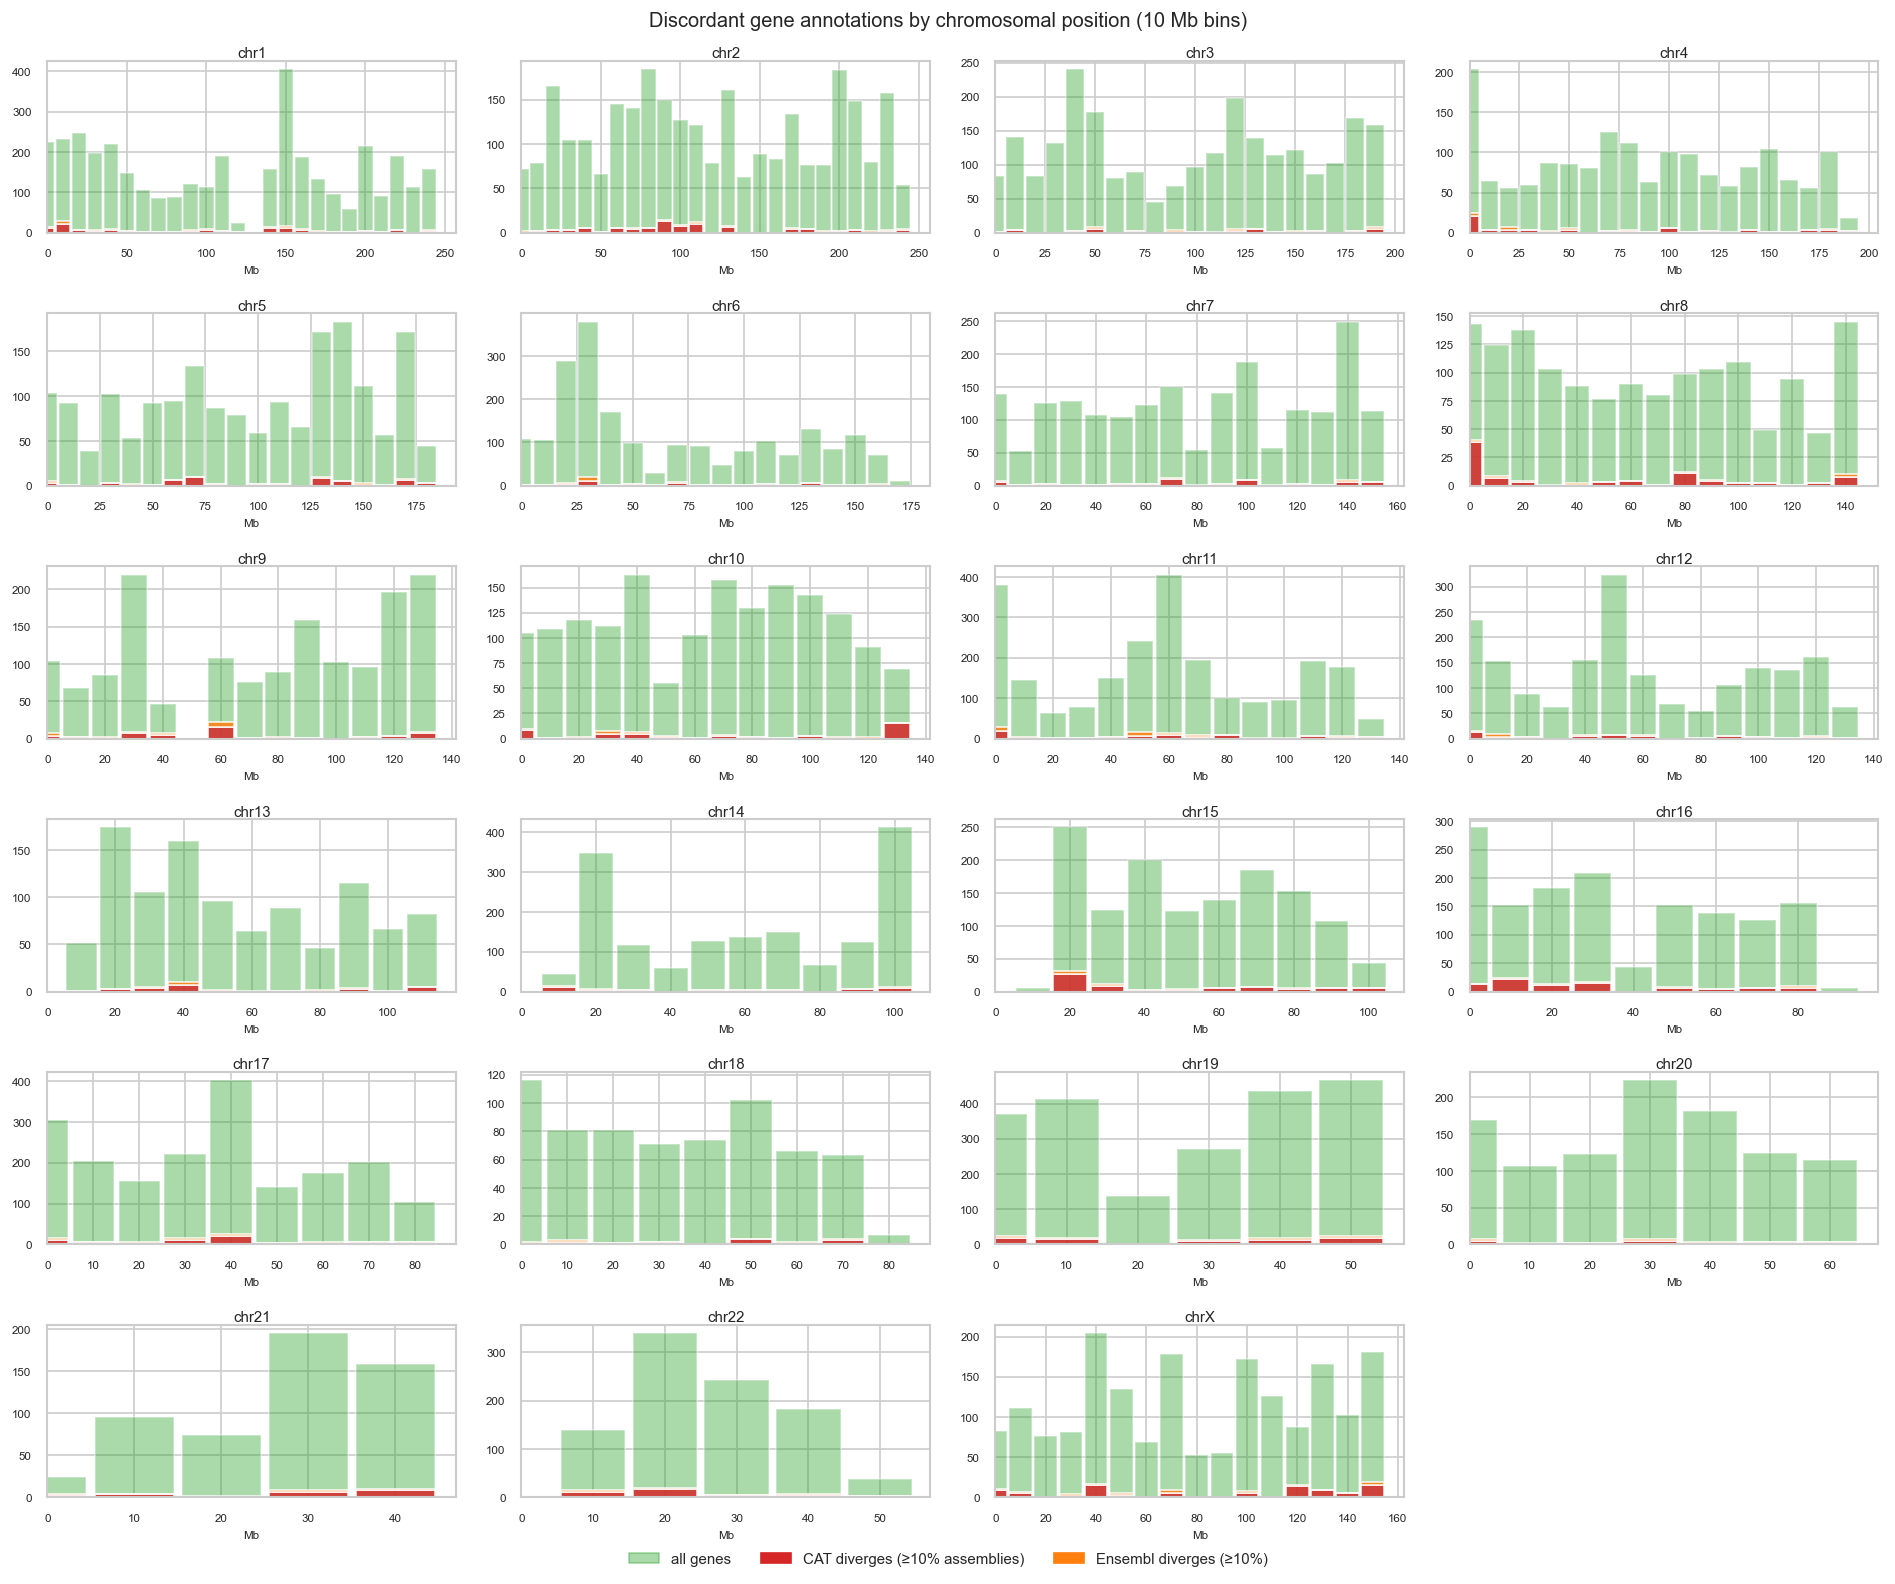

In [6]:
BIN_MB = 10
BIN_BP = BIN_MB * 1_000_000

s1g_chr = s1g[s1g['chrom'].notna() & s1g['midpoint'].notna()].copy()
s1g_chr['chrom'] = s1g_chr['chrom'].astype(str)
s1g_chr['bin'] = (s1g_chr['midpoint'] // BIN_BP).astype(int)
s1g_chr['is_cat_diverges'] = s1g_chr['pct_cat_specific_divergence'].fillna(0) >= 10
s1g_chr['is_ens_diverges'] = s1g_chr['pct_ensembl_specific_divergence'].fillna(0) >= 10

plot_chroms = [c for c in CHROM_ORDER if c not in ('Y', 'MT') and c in s1g_chr['chrom'].values]
ncols = 4
nrows = -(-len(plot_chroms) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.2), sharey=False)
axes = axes.flatten()

for ax, chrom in zip(axes, plot_chroms):
    sub = s1g_chr[s1g_chr['chrom'] == chrom]
    if sub.empty:
        ax.set_visible(False)
        continue
    bins = sub.groupby('bin').agg(
        n_genes=('gene_name', 'count'),
        n_cat=('is_cat_diverges', 'sum'),
        n_ens=('is_ens_diverges', 'sum'),
    ).reset_index()
    bins['mb'] = bins['bin'] * BIN_MB

    ax.bar(bins['mb'], bins['n_genes'], width=BIN_MB * 0.9,
           color=DIV_PALETTE['both_agree_reference'], alpha=0.4)
    ax.bar(bins['mb'], bins['n_cat'], width=BIN_MB * 0.9,
           color=DIV_PALETTE['cat_specific_divergence'], alpha=0.85)
    ax.bar(bins['mb'], bins['n_ens'], width=BIN_MB * 0.9,
           bottom=bins['n_cat'],
           color=DIV_PALETTE['ensembl_specific_divergence'], alpha=0.85)
    ax.set_title(f'chr{chrom}', fontsize=9, pad=2)
    ax.set_xlabel('Mb', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.set_xlim(left=0)

for ax in axes[len(plot_chroms):]:
    ax.set_visible(False)

handles = [
    mpatches.Patch(color=DIV_PALETTE['both_agree_reference'], alpha=0.4, label='all genes'),
    mpatches.Patch(color=DIV_PALETTE['cat_specific_divergence'], label='CAT diverges (≥10% assemblies)'),
    mpatches.Patch(color=DIV_PALETTE['ensembl_specific_divergence'], label='Ensembl diverges (≥10%)'),
]
fig.legend(handles=handles, loc='lower center', fontsize=9, frameon=False, ncol=3,
           bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Discordant gene annotations by chromosomal position (10 Mb bins)', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'chrom_density_discordant.png', bbox_inches='tight')
plt.show()

## 6. CDS change type: Ensembl vs CAT vs GRCh38

The key asymmetry: how often does each annotator lose/gain/shift the coding sequence relative to GRCh38?

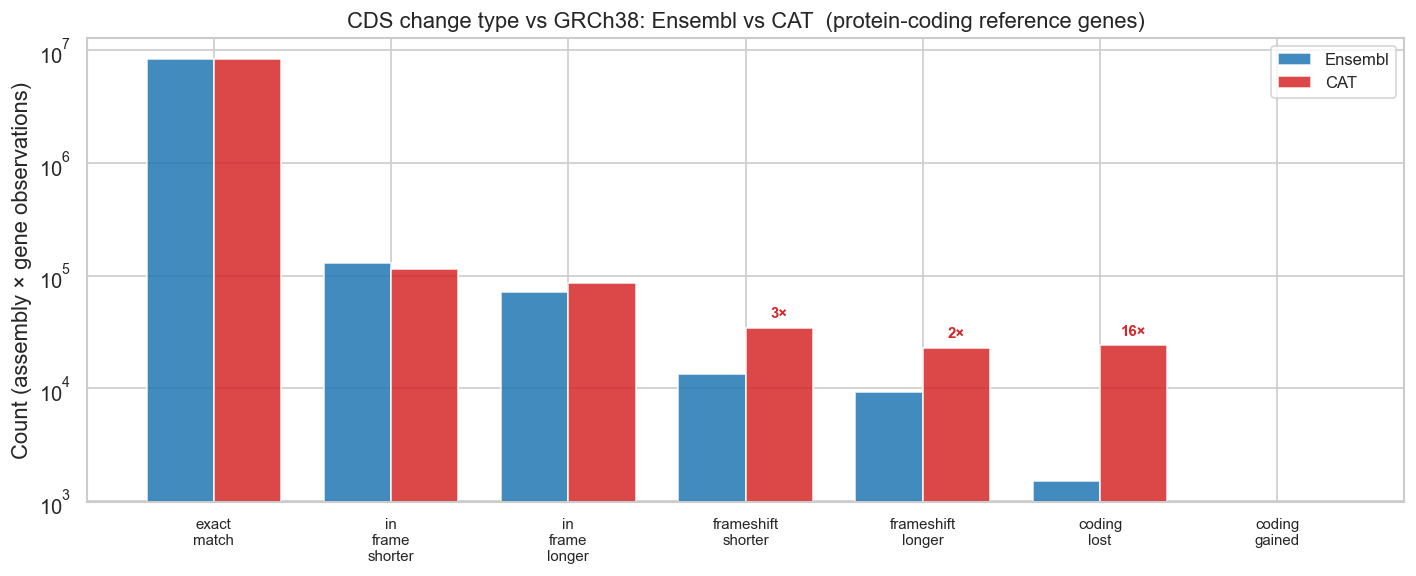

In [7]:
div_coding = div[div['is_coding'] == True].dropna(subset=['gene_name'])

ens_counts = div_coding['ens_cds_change_type'].value_counts()
cat_counts = div_coding['cat_cds_change_type'].value_counts()

change_order = ['exact_match', 'in_frame_shorter', 'in_frame_longer',
                'frameshift_shorter', 'frameshift_longer', 'coding_lost', 'coding_gained']
change_order = [c for c in change_order if c in ens_counts.index or c in cat_counts.index]

ens_vals = [ens_counts.get(c, 0) for c in change_order]
cat_vals = [cat_counts.get(c, 0) for c in change_order]

x = np.arange(len(change_order))
width = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, ens_vals, width, label='Ensembl', color='#1f77b4', alpha=0.85)
ax.bar(x + width/2, cat_vals, width, label='CAT',     color='#d62728', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in change_order], fontsize=9)
ax.set_ylabel('Count (assembly × gene observations)')
ax.set_title('CDS change type vs GRCh38: Ensembl vs CAT  (protein-coding reference genes)')
ax.legend(fontsize=10)
ax.set_yscale('log')

# Annotate fold differences for non-trivial categories
for i, cat in enumerate(change_order):
    ev, cv = ens_vals[i], cat_vals[i]
    if ev == 0 or cv == 0:
        continue
    fold = cv / ev
    if abs(np.log10(fold)) > 0.3:  # >2× difference
        higher = x[i] + width/2 if fold > 1 else x[i] - width/2
        val    = cv if fold > 1 else ev
        label  = f'{fold:.0f}×' if fold > 1 else f'1/{1/fold:.0f}×'
        ax.annotate(label, xy=(higher, val), xytext=(0, 6),
                    textcoords='offset points', ha='center', fontsize=9,
                    color='#d62728' if fold > 1 else '#1f77b4', fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'cds_change_type_comparison.png', bbox_inches='tight')
plt.show()

## 7. Reference CDS match rate: Ensembl vs CAT per gene

Each point is one gene. How consistently does each annotator reproduce the GRCh38 CDS across 462 assemblies?  
Points below the diagonal = CAT matches GRCh38 less often than Ensembl for that gene.

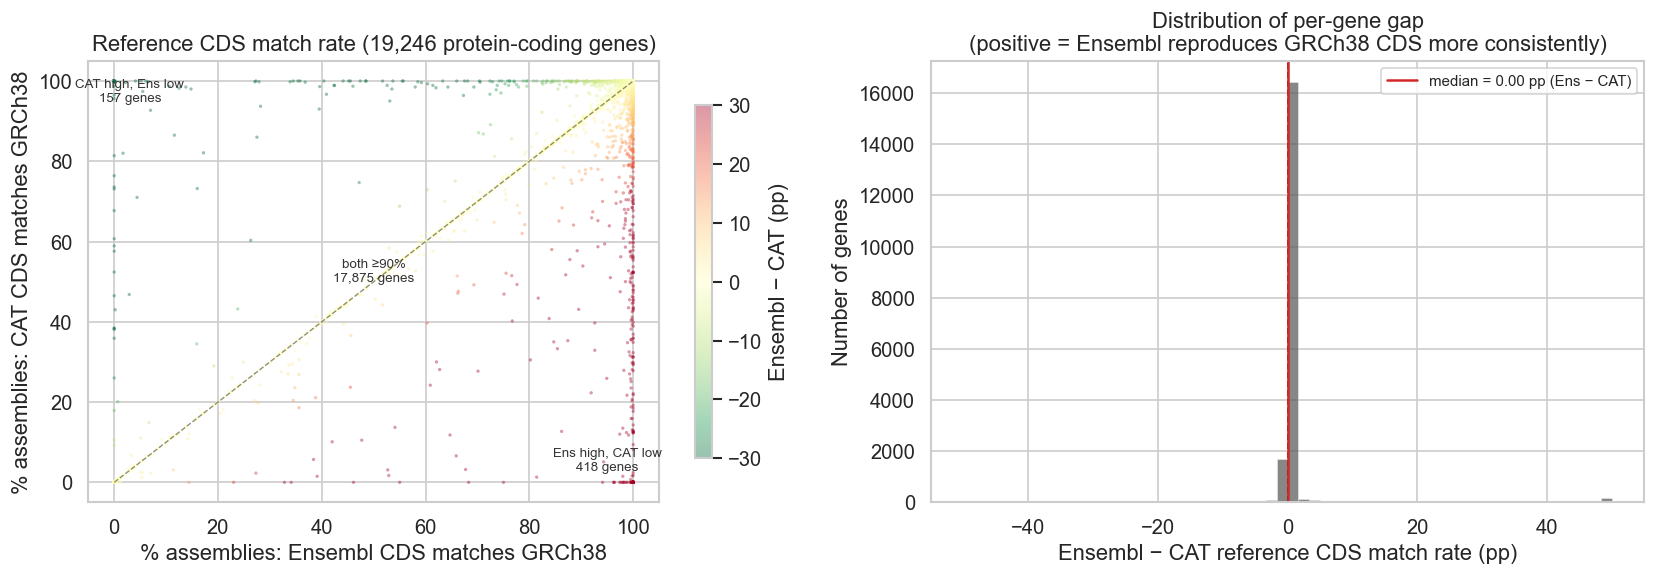

Median Ens−CAT gap: 0.00 pp
Genes where CAT ≥10 pp worse: 418
Genes where Ensembl ≥10 pp worse: 157


In [8]:
s1_coding = s1g[s1g['ensembl_biotype'] == 'protein_coding'].dropna(
    subset=['pct_ens_cds_match_ref', 'pct_cat_cds_match_ref']
).copy()
diff = s1_coding['pct_ens_cds_match_ref'] - s1_coding['pct_cat_cds_match_ref']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sc = ax.scatter(
    s1_coding['pct_ens_cds_match_ref'], s1_coding['pct_cat_cds_match_ref'],
    c=diff, cmap='RdYlGn_r', vmin=-30, vmax=30,
    s=4, alpha=0.4, linewidths=0,
)
ax.plot([0, 100], [0, 100], 'k--', lw=0.8, alpha=0.5)
ax.set_xlabel('% assemblies: Ensembl CDS matches GRCh38')
ax.set_ylabel('% assemblies: CAT CDS matches GRCh38')
ax.set_title(f'Reference CDS match rate ({len(s1_coding):,} protein-coding genes)')
plt.colorbar(sc, ax=ax, label='Ensembl − CAT (pp)', shrink=0.8)

# Quadrant counts (90% threshold)
for (xe, ye), label in [
    ((95, 3),  f"Ens high, CAT low\n{((diff >= 10)).sum():,} genes"),
    ((3,  95), f"CAT high, Ens low\n{((diff <= -10)).sum():,} genes"),
    ((50, 50), f"both ≥90%\n{((s1_coding.pct_ens_cds_match_ref >= 90) & (s1_coding.pct_cat_cds_match_ref >= 90)).sum():,} genes"),
]:
    ax.text(xe, ye, label, fontsize=8, ha='center', color='#333')

ax2 = axes[1]
ax2.hist(diff.clip(-50, 50), bins=60, color='#555', alpha=0.7, edgecolor='white', linewidth=0.3)
ax2.axvline(0, color='k', lw=1, ls='--')
ax2.axvline(diff.median(), color='#d62728', lw=1.5,
            label=f'median = {diff.median():.2f} pp (Ens − CAT)')
ax2.set_xlabel('Ensembl − CAT reference CDS match rate (pp)')
ax2.set_ylabel('Number of genes')
ax2.set_title('Distribution of per-gene gap\n(positive = Ensembl reproduces GRCh38 CDS more consistently)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'cds_ref_match_scatter.png', bbox_inches='tight')
plt.show()
print(f'Median Ens−CAT gap: {diff.median():.2f} pp')
print(f'Genes where CAT ≥10 pp worse: {(diff >= 10).sum():,}')
print(f'Genes where Ensembl ≥10 pp worse: {(diff <= -10).sum():,}')

## 8. Concordance by biotype

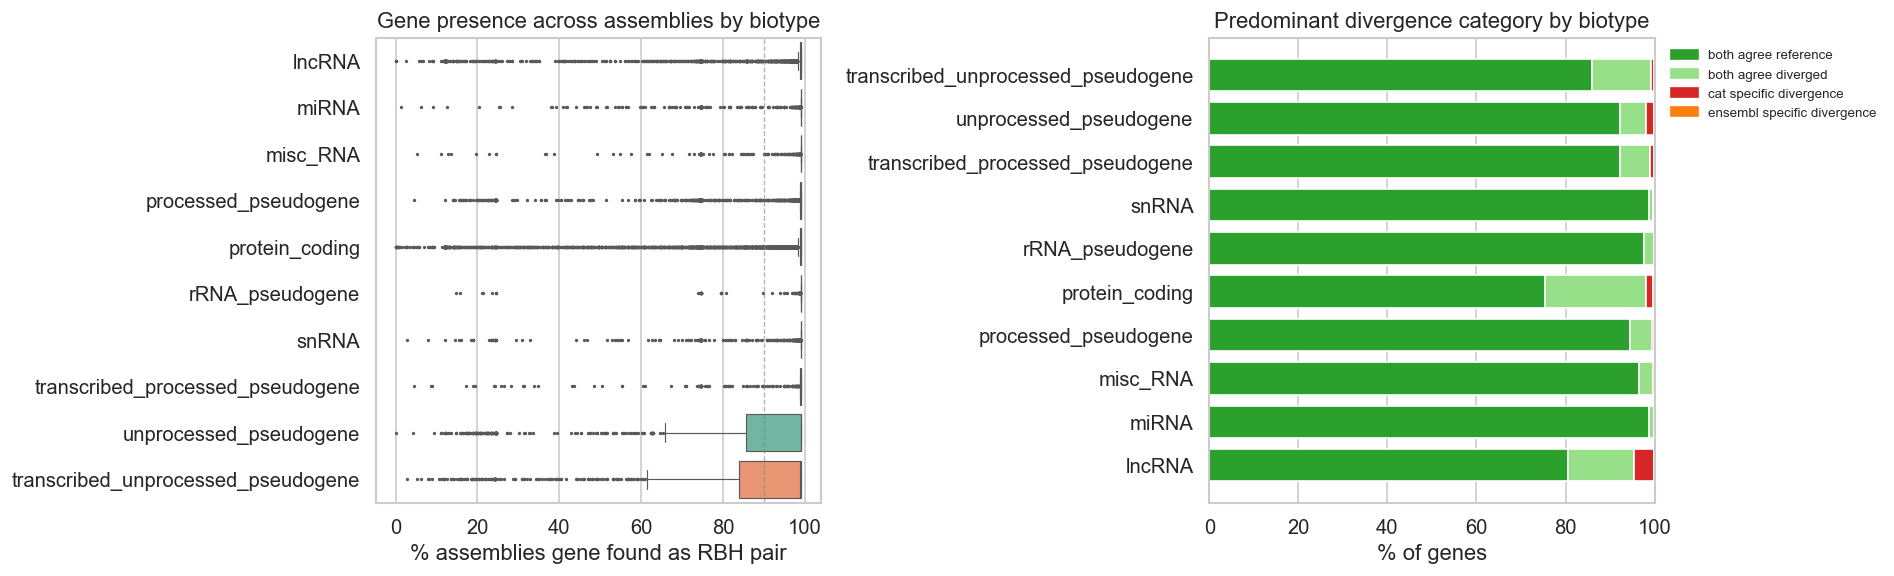

In [9]:
top_biotypes = s1['ensembl_biotype'].value_counts().head(10).index.tolist()
s1_bt = s1[s1['ensembl_biotype'].isin(top_biotypes)].copy()
order = s1_bt.groupby('ensembl_biotype')['pct_assemblies_both'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gene presence across assemblies by biotype
ax = axes[0]
sns.boxplot(data=s1_bt, y='ensembl_biotype', x='pct_assemblies_both',
            order=order, palette='Set2', ax=ax, linewidth=0.7, fliersize=1)
ax.set_xlabel('% assemblies gene found as RBH pair')
ax.set_ylabel('')
ax.set_title('Gene presence across assemblies by biotype')
ax.axvline(90, color='grey', ls='--', lw=0.8, alpha=0.6)

# Predominant divergence category by biotype
ax = axes[1]
bt_div = (s1_bt.groupby(['ensembl_biotype', 'predominant_divergence_category'])
          .size().unstack(fill_value=0).reindex(order))
bt_div_pct = bt_div.div(bt_div.sum(axis=1), axis=0) * 100
plot_cats = [c for c in DIV_ORDER if c in bt_div_pct.columns]
bottom = np.zeros(len(bt_div_pct))
for cat in plot_cats:
    vals = bt_div_pct.get(cat, pd.Series(0, index=bt_div_pct.index)).values
    ax.barh(range(len(bt_div_pct)), vals, left=bottom,
            color=DIV_PALETTE[cat], height=0.75)
    bottom += vals
ax.set_yticks(range(len(bt_div_pct)))
ax.set_yticklabels(bt_div_pct.index)
ax.set_xlabel('% of genes')
ax.set_title('Predominant divergence category by biotype')
ax.set_xlim(0, 100)
handles = [mpatches.Patch(color=DIV_PALETTE[c], label=c.replace('_', ' ')) for c in plot_cats]
ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'biotype_concordance.png', bbox_inches='tight')
plt.show()

## 9. Structural differences vs GRCh38

When the annotation differs from GRCh38, how large is the structural change?  
(Only non-exact-match coding genes shown.)

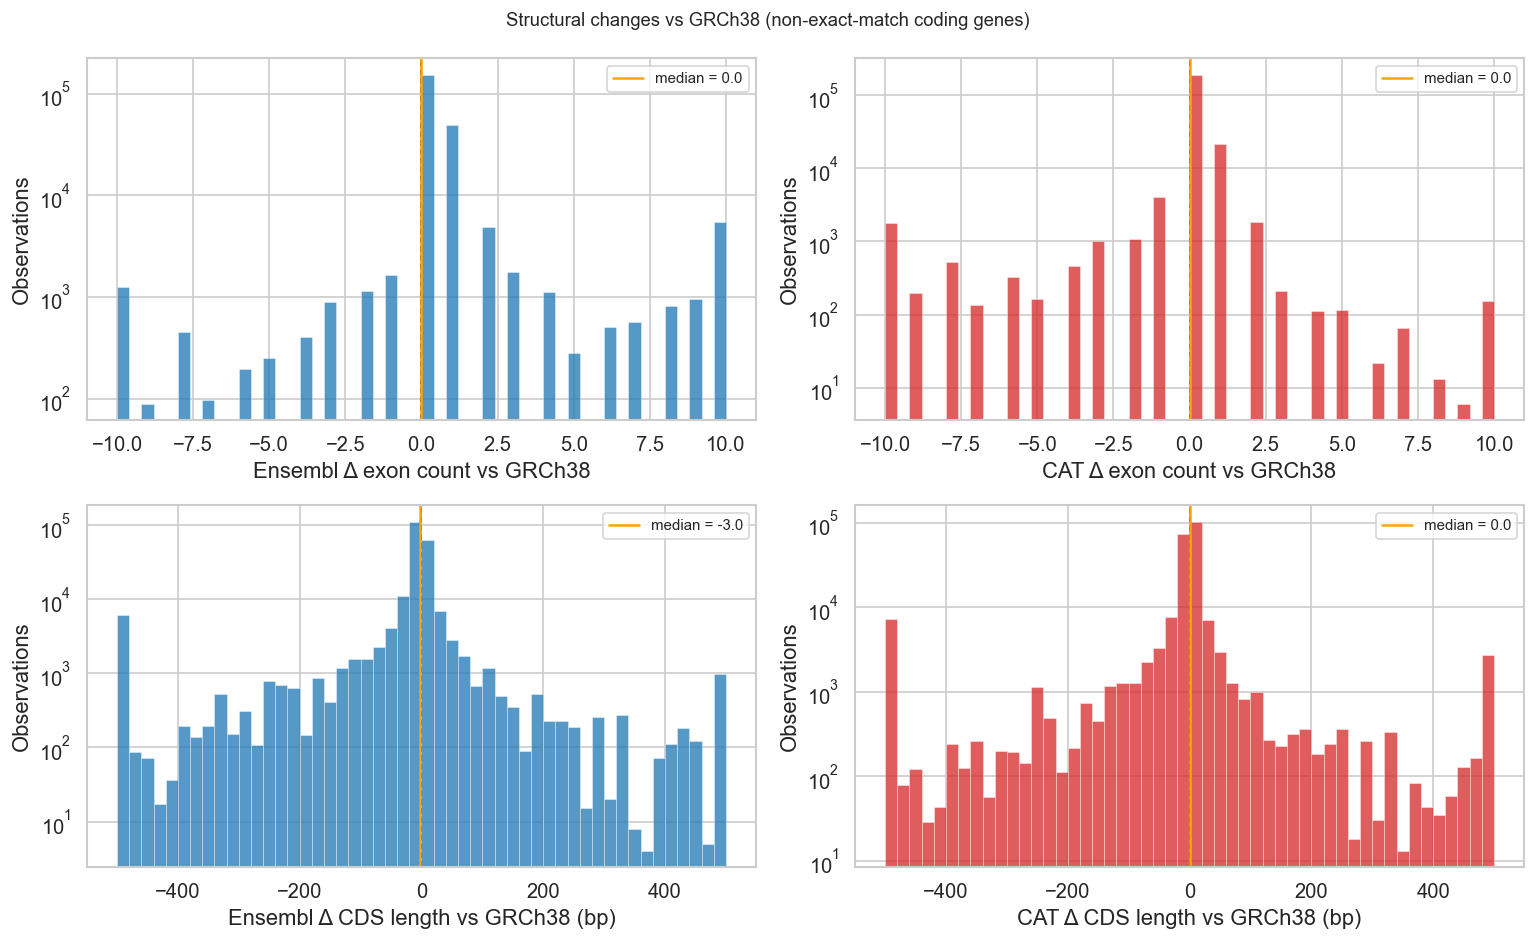

In [10]:
div_changed = div[
    (div['is_coding'] == True) &
    (~div['ens_cds_change_type'].isin(['non_coding', 'exact_match', None])) &
    (div['ens_delta_n_exons'].notna())
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col, label, clip, color in [
    (axes[0,0], 'ens_delta_n_exons',    'Ensembl Δ exon count vs GRCh38',     (-10, 10),   '#1f77b4'),
    (axes[0,1], 'cat_delta_n_exons',    'CAT Δ exon count vs GRCh38',          (-10, 10),   '#d62728'),
    (axes[1,0], 'ens_delta_cds_length', 'Ensembl Δ CDS length vs GRCh38 (bp)', (-500, 500), '#1f77b4'),
    (axes[1,1], 'cat_delta_cds_length', 'CAT Δ CDS length vs GRCh38 (bp)',     (-500, 500), '#d62728'),
]:
    vals = div_changed[col].clip(*clip)
    ax.hist(vals, bins=50, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='k', ls='--', lw=1)
    med = div_changed[col].median()
    ax.axvline(med, color='orange', ls='-', lw=1.5, label=f'median = {med:.1f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Observations')
    ax.set_yscale('log')
    ax.legend(fontsize=9)

plt.suptitle('Structural changes vs GRCh38 (non-exact-match coding genes)', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'structural_deltas.png', bbox_inches='tight')
plt.show()

## 10. Most discordant genes

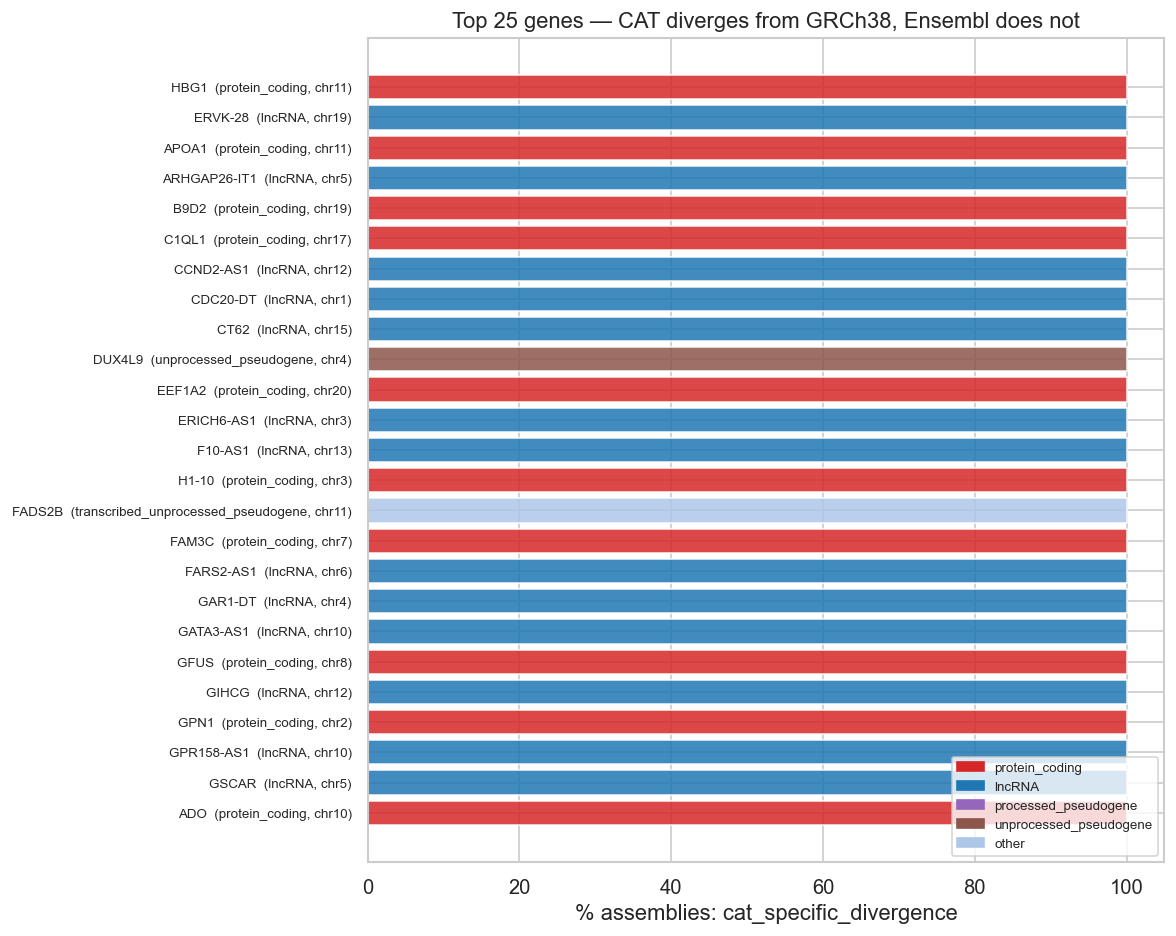


Top 25 CAT-discordant genes:


,gene_name,ensembl_biotype,chrom,n_assemblies_assessed,pct_cat_specific_divergence,pct_cat_coding_lost,pct_cat_frameshift_ref,predominant_cat_cds_change_type
0,ADO,protein_coding,10,458,100.0,0.0,0.0,in_frame_shorter
1,APOA1,protein_coding,11,456,100.0,0.0,0.0,exact_match
2,ARHGAP26-IT1,lncRNA,5,458,100.0,NaN,NaN,NaN
3,B9D2,protein_coding,19,386,100.0,0.0,0.0,exact_match
4,C1QL1,protein_coding,17,458,100.0,0.0,0.0,in_frame_shorter
5,CCND2-AS1,lncRNA,12,458,100.0,NaN,NaN,NaN
6,CDC20-DT,lncRNA,1,458,100.0,NaN,NaN,NaN
7,CT62,lncRNA,15,458,100.0,NaN,NaN,NaN
8,DUX4L9,unprocessed_pseudogene,4,448,100.0,NaN,NaN,NaN
9,EEF1A2,protein_coding,20,456,100.0,0.0,0.0,in_frame_longer


In [11]:
show_cols = ['gene_name', 'ensembl_biotype', 'chrom', 'n_assemblies_assessed',
             'pct_cat_specific_divergence', 'pct_cat_coding_lost',
             'pct_cat_frameshift_ref', 'predominant_cat_cds_change_type']
show_cols = [c for c in show_cols if c in s1g.columns]

top_cat = s1g.dropna(subset=['pct_cat_specific_divergence']).nlargest(25, 'pct_cat_specific_divergence')
top_cat_sorted = top_cat.sort_values('pct_cat_specific_divergence')

fig, ax = plt.subplots(figsize=(10, 8))
bt_color_map = {'protein_coding': '#d62728', 'lncRNA': '#1f77b4',
                'processed_pseudogene': '#9467bd', 'unprocessed_pseudogene': '#8c564b'}
colors = [bt_color_map.get(bt, '#aec7e8') for bt in top_cat_sorted['ensembl_biotype']]
ax.barh(range(len(top_cat_sorted)), top_cat_sorted['pct_cat_specific_divergence'],
        color=colors, alpha=0.85)
ax.set_yticks(range(len(top_cat_sorted)))
chrom_label = top_cat_sorted['chrom'].fillna('?').astype(str)
ax.set_yticklabels([f"{r.gene_name}  ({r.ensembl_biotype}, chr{c})"
                    for r, c in zip(top_cat_sorted.itertuples(), chrom_label)], fontsize=8)
ax.set_xlabel('% assemblies: cat_specific_divergence')
ax.set_title('Top 25 genes — CAT diverges from GRCh38, Ensembl does not')
handles = [mpatches.Patch(color=c, label=bt) for bt, c in bt_color_map.items()]
handles.append(mpatches.Patch(color='#aec7e8', label='other'))
ax.legend(handles=handles, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'top_cat_discordant_genes.png', bbox_inches='tight')
plt.show()

print('\nTop 25 CAT-discordant genes:')
display(top_cat[show_cols].reset_index(drop=True))

## 11. Assembly-level variation

Do some HPRC assemblies produce systematically more discordant annotations?

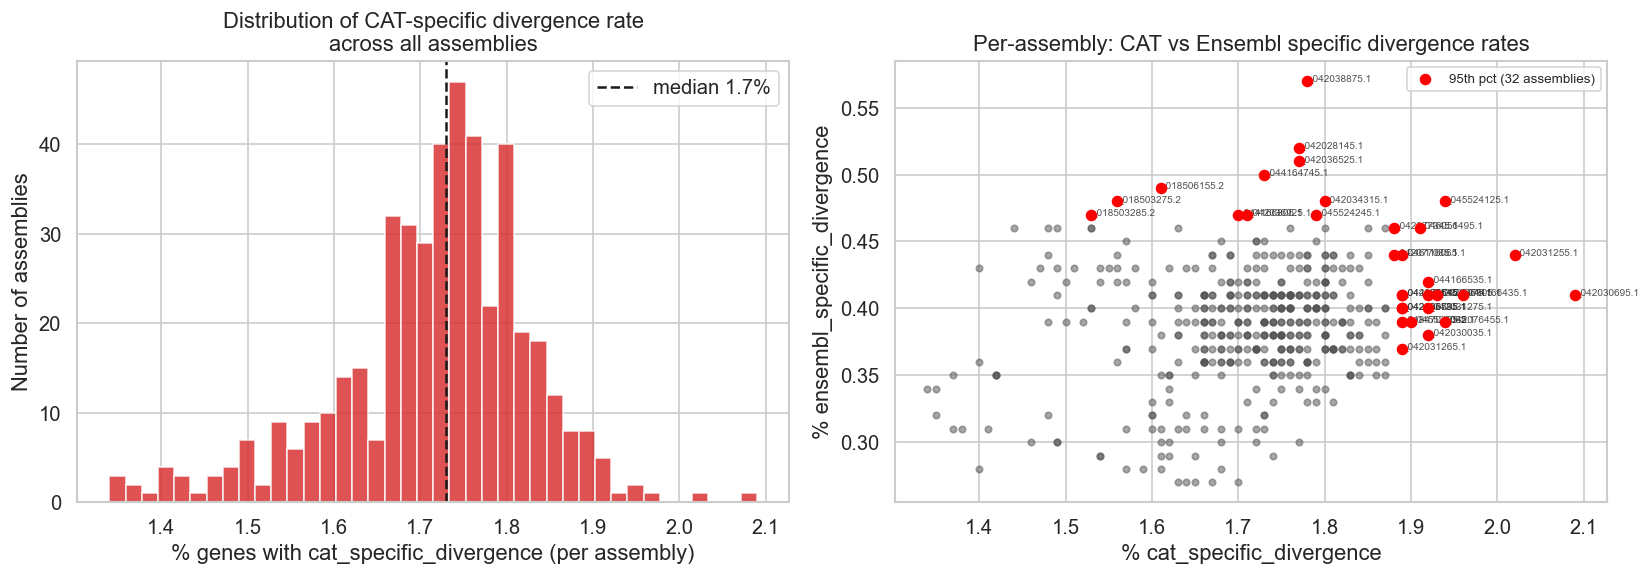

Outlier assemblies (>95th pct on either axis):
assembly_accession  pct_cat_specific_divergence  pct_ensembl_specific_divergence  _total
   GCA_018470425.2                         1.89                             0.39   39587
   GCA_018503275.2                         1.56                             0.48   42138
   GCA_018503285.2                         1.53                             0.47   42244
   GCA_018506155.2                         1.61                             0.49   40562
   GCA_042028145.1                         1.77                             0.52   41133
   GCA_042030035.1                         1.92                             0.38   39701
   GCA_042030695.1                         2.09                             0.41   41018
   GCA_042031255.1                         2.02                             0.44   40971
   GCA_042031265.1                         1.89                             0.37   39666
   GCA_042031275.1                         1.92                

In [12]:
assm_div = (div.dropna(subset=['divergence_category'])
            .groupby(['assembly_accession', 'divergence_category'])
            .size().unstack(fill_value=0).reset_index())
assm_div.columns.name = None
for cat in DIV_ORDER:
    if cat not in assm_div.columns:
        assm_div[cat] = 0
assm_div['_total'] = assm_div[DIV_ORDER].sum(axis=1)
for cat in DIV_ORDER:
    assm_div[f'pct_{cat}'] = (assm_div[cat] / assm_div['_total'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(assm_div['pct_cat_specific_divergence'], bins=40,
        color=DIV_PALETTE['cat_specific_divergence'], alpha=0.8, edgecolor='white')
med = assm_div['pct_cat_specific_divergence'].median()
ax.axvline(med, color='k', ls='--', lw=1.5, label=f'median {med:.1f}%')
ax.set_xlabel('% genes with cat_specific_divergence (per assembly)')
ax.set_ylabel('Number of assemblies')
ax.set_title('Distribution of CAT-specific divergence rate\nacross all assemblies')
ax.legend()

ax = axes[1]
ax.scatter(assm_div['pct_cat_specific_divergence'],
           assm_div['pct_ensembl_specific_divergence'],
           s=15, alpha=0.5, color='#555')
thresh_cat = assm_div['pct_cat_specific_divergence'].quantile(0.95)
thresh_ens = assm_div['pct_ensembl_specific_divergence'].quantile(0.95)
outliers = assm_div[
    (assm_div['pct_cat_specific_divergence'] > thresh_cat) |
    (assm_div['pct_ensembl_specific_divergence'] > thresh_ens)
]
ax.scatter(outliers['pct_cat_specific_divergence'], outliers['pct_ensembl_specific_divergence'],
           s=35, color='red', zorder=5, label=f'95th pct ({len(outliers)} assemblies)')
for _, r in outliers.iterrows():
    ax.annotate(r['assembly_accession'][-12:],
                (r['pct_cat_specific_divergence'], r['pct_ensembl_specific_divergence']),
                fontsize=6, alpha=0.8)
ax.set_xlabel('% cat_specific_divergence')
ax.set_ylabel('% ensembl_specific_divergence')
ax.set_title('Per-assembly: CAT vs Ensembl specific divergence rates')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'assembly_divergence.png', bbox_inches='tight')
plt.show()

print(f'Outlier assemblies (>95th pct on either axis):')
print(outliers[['assembly_accession', 'pct_cat_specific_divergence',
                'pct_ensembl_specific_divergence', '_total']].to_string(index=False))

## 12. coding_lost deep dive

CAT loses coding ability 16× more often than Ensembl. Which genes, which chromosomes?

Genes with pct_cat_coding_lost ≥ 10%: 139
Genes with pct_cat_coding_lost ≥ 50%: 32


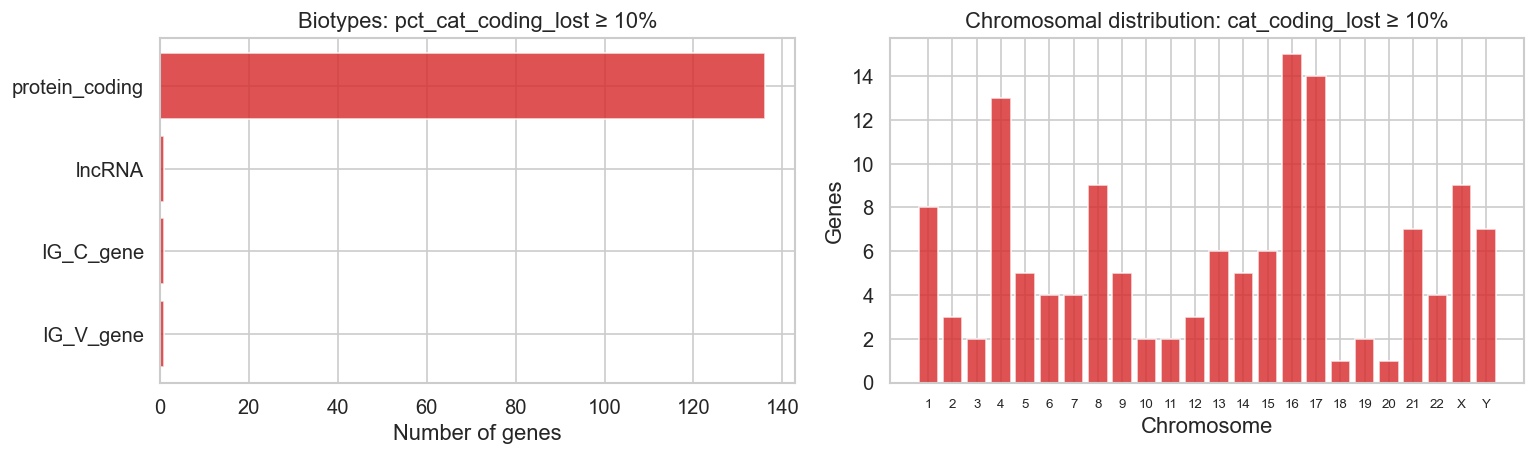

,gene_name,ensembl_biotype,chrom,n_assemblies_assessed,pct_cat_coding_lost,pct_ens_coding_lost,pct_cat_cds_match_ref,pct_ens_cds_match_ref
0,PCDHB16,protein_coding,5,56,100.0,0.0,0.0,100.0
1,PRY,protein_coding,NaN,4,100.0,0.0,0.0,75.0
2,PRY2,protein_coding,NaN,2,100.0,0.0,0.0,100.0
3,TSTD3,protein_coding,6,458,100.0,0.0,0.0,99.8
4,NAGLU,protein_coding,17,442,99.3,0.0,0.7,99.5
5,DUX4,protein_coding,4,3,93.5,0.0,3.2,67.7
6,CDK12,protein_coding,17,452,87.6,0.0,12.4,100.0
7,COX10,protein_coding,17,458,87.3,0.0,12.7,100.0
8,SP3,protein_coding,2,455,85.7,0.0,14.3,100.0
9,SSU72L4,protein_coding,11,355,81.2,0.4,18.8,99.6


In [13]:
cat_lost = s1g[s1g['pct_cat_coding_lost'].fillna(0) >= 10].copy()
print(f'Genes with pct_cat_coding_lost ≥ 10%: {len(cat_lost):,}')
print(f'Genes with pct_cat_coding_lost ≥ 50%: {(s1g["pct_cat_coding_lost"].fillna(0) >= 50).sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bt = cat_lost['ensembl_biotype'].value_counts().head(8)
ax.barh(bt.index[::-1], bt.values[::-1], color='#d62728', alpha=0.8)
ax.set_xlabel('Number of genes')
ax.set_title('Biotypes: pct_cat_coding_lost ≥ 10%')

ax = axes[1]
chr_counts = (cat_lost.dropna(subset=['chrom'])
              .groupby('chrom').size()
              .reindex([c for c in CHROM_ORDER if c in cat_lost['chrom'].astype(str).values])
              .fillna(0))
ax.bar(range(len(chr_counts)), chr_counts.values, color='#d62728', alpha=0.8)
ax.set_xticks(range(len(chr_counts)))
ax.set_xticklabels(chr_counts.index, fontsize=8)
ax.set_xlabel('Chromosome')
ax.set_ylabel('Genes')
ax.set_title('Chromosomal distribution: cat_coding_lost ≥ 10%')

plt.tight_layout()
plt.savefig(FIG_DIR / 'coding_lost_breakdown.png', bbox_inches='tight')
plt.show()

show_cl = ['gene_name', 'ensembl_biotype', 'chrom', 'n_assemblies_assessed',
           'pct_cat_coding_lost', 'pct_ens_coding_lost',
           'pct_cat_cds_match_ref', 'pct_ens_cds_match_ref']
show_cl = [c for c in show_cl if c in cat_lost.columns]
display(cat_lost.nlargest(20, 'pct_cat_coding_lost')[show_cl].reset_index(drop=True))

## 12b. Ensembl coding_lost deep dive

Symmetric view to Section 12. Both annotators can fail — which genes does Ensembl systematically lose?

Genes with pct_ens_coding_lost ≥ 10%: 3
Genes with pct_cat_coding_lost ≥ 10%: 139  (46.3× more than Ensembl)
Genes where BOTH lose CDS in ≥10% assemblies: 2


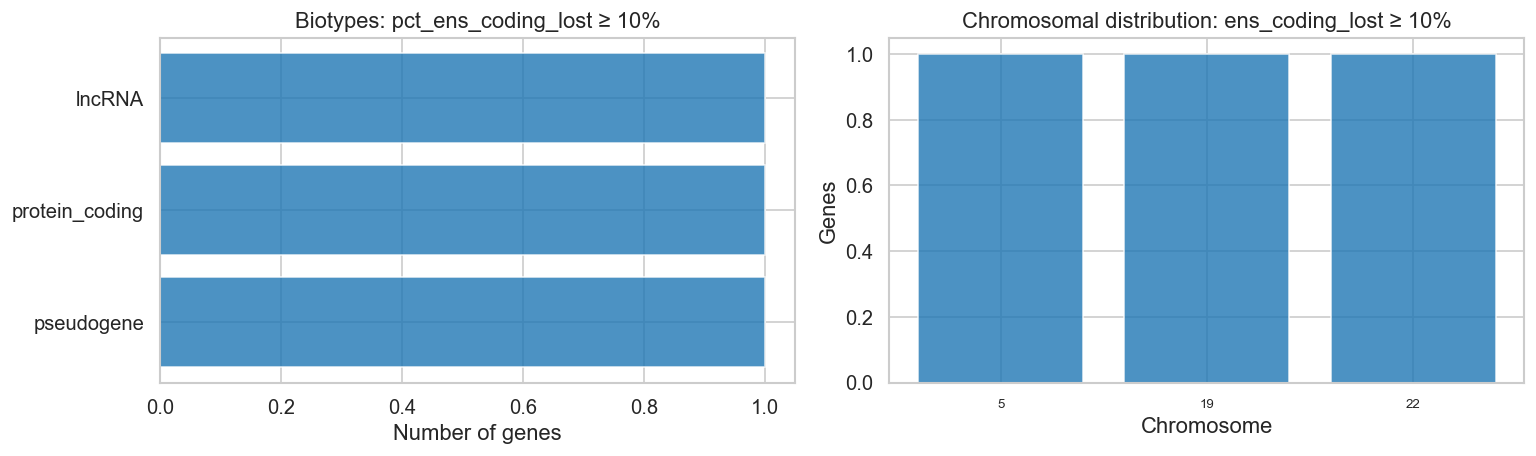


Top 20 genes by pct_ens_coding_lost:


,gene_name,ensembl_biotype,chrom,n_assemblies_assessed,pct_ens_coding_lost,pct_cat_coding_lost,pct_ens_cds_match_ref,pct_cat_cds_match_ref
0,RPSA2,pseudogene,19,456,98.0,0.0,2.0,99.8
1,CAST,lncRNA,5,458,53.6,53.6,46.4,46.3
2,ELFN2,protein_coding,22,458,46.4,46.4,53.3,53.5


In [14]:
ens_lost = s1g[s1g['pct_ens_coding_lost'].fillna(0) >= 10].copy()
cat_lost_n = (s1g['pct_cat_coding_lost'].fillna(0) >= 10).sum()
print(f'Genes with pct_ens_coding_lost ≥ 10%: {len(ens_lost):,}')
print(f'Genes with pct_cat_coding_lost ≥ 10%: {cat_lost_n:,}  ({cat_lost_n / max(len(ens_lost),1):.1f}× more than Ensembl)')
print(f'Genes where BOTH lose CDS in ≥10% assemblies: '
      f'{((s1g["pct_cat_coding_lost"].fillna(0) >= 10) & (s1g["pct_ens_coding_lost"].fillna(0) >= 10)).sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bt = ens_lost['ensembl_biotype'].value_counts().head(8)
ax.barh(bt.index[::-1], bt.values[::-1], color='#1f77b4', alpha=0.8)
ax.set_xlabel('Number of genes')
ax.set_title('Biotypes: pct_ens_coding_lost ≥ 10%')

ax = axes[1]
chr_counts = (ens_lost.dropna(subset=['chrom'])
              .assign(chrom=lambda d: d['chrom'].astype(str))
              .groupby('chrom').size()
              .reindex([c for c in CHROM_ORDER if c in ens_lost['chrom'].astype(str).values])
              .fillna(0))
ax.bar(range(len(chr_counts)), chr_counts.values, color='#1f77b4', alpha=0.8)
ax.set_xticks(range(len(chr_counts)))
ax.set_xticklabels(chr_counts.index, fontsize=8)
ax.set_xlabel('Chromosome'); ax.set_ylabel('Genes')
ax.set_title('Chromosomal distribution: ens_coding_lost ≥ 10%')

plt.tight_layout()
plt.savefig(FIG_DIR / 'ens_coding_lost_breakdown.png', bbox_inches='tight')
plt.show()

show_el = ['gene_name', 'ensembl_biotype', 'chrom', 'n_assemblies_assessed',
           'pct_ens_coding_lost', 'pct_cat_coding_lost',
           'pct_ens_cds_match_ref', 'pct_cat_cds_match_ref']
show_el = [c for c in show_el if c in ens_lost.columns]
print('\nTop 20 genes by pct_ens_coding_lost:')
display(ens_lost.nlargest(20, 'pct_ens_coding_lost')[show_el].reset_index(drop=True))

## 12c. Metric parity + structural characterisation of CAT coding_lost genes

**Metric parity**: `load_gene_models_gff()` in `compute_grch38_divergence.py` is called identically for both annotators. `is_coding = cds_length > 0`. The 46× asymmetry is genuine: CAT GFF3 files omit CDS annotations when the reading frame cannot be transferred, while Ensembl projection always carries over CDS features.

**Verification**: for `coding_lost` observations, `cat_delta_cds_length` should be strongly negative (≈ −ref_cds_length), confirming the projected model has CDS = 0 (full dropout, not truncation).

**Structural characterisation**: are CAT coding_lost genes longer / more complex than average? **Chr17 drill-down**: CDK12, COX10, NAGLU — are they clustered at a specific locus?

=== Metric parity validation ===
CAT coding_lost observations: 24,171
  cat_delta_cds_length: median=-1395  mean=-1753  pct < -100: 99.8%
  → Strongly negative delta confirms CDS = 0 in CAT GFF3 (full dropout, not truncation)

Ensembl coding_lost observations: 1,518
  ens_delta_cds_length: median=-2376  mean=-1784

Conclusion: metric defined identically for both annotators. Asymmetry is real.

=== Structural features: CAT coding_lost autosomal genes (n=121) ===
Gene length: CAT-lost median 15 kb  vs all autosomal 7 kb

Chr17 CAT coding_lost genes (n=14):


,gene_name,pct_cat_coding_lost,pct_ens_coding_lost,n_assemblies_assessed,start,end
0,NAGLU,99.3,0.0,442,42536241.0,42544449.0
1,CDK12,87.6,0.0,452,39461437.0,39567559.0
2,COX10,87.3,0.0,458,14069490.0,14231736.0
3,KRTAP9-8,43.7,0.0,414,41237999.0,41239004.0
4,ARL17B,39.0,0.0,381,46274184.0,46361766.0
5,NSF,19.9,0.0,395,46590669.0,46757679.0
6,NEUROD2,19.2,0.0,453,39603536.0,39609777.0
7,TBC1D3C,18.2,0.0,183,38057693.0,38068634.0
8,TBC1D3H,16.2,0.0,259,36377531.0,36388435.0
9,GRAPL,14.6,0.0,80,19127535.0,19162274.0



Uniformity of failure across assemblies (top 10 genes):


,gene_name,n_assemblies_failing,n_assemblies_assessed,pct_cat_coding_lost
0,PCDHB16,56,56,100.0
1,PRY,4,4,100.0
2,PRY2,2,2,100.0
3,TSTD3,458,458,100.0
4,NAGLU,439,442,99.3
5,DUX4,3,3,93.5
6,CDK12,396,452,87.6
7,COX10,400,458,87.3
8,SP3,390,455,85.7
9,SSU72L4,321,355,81.2


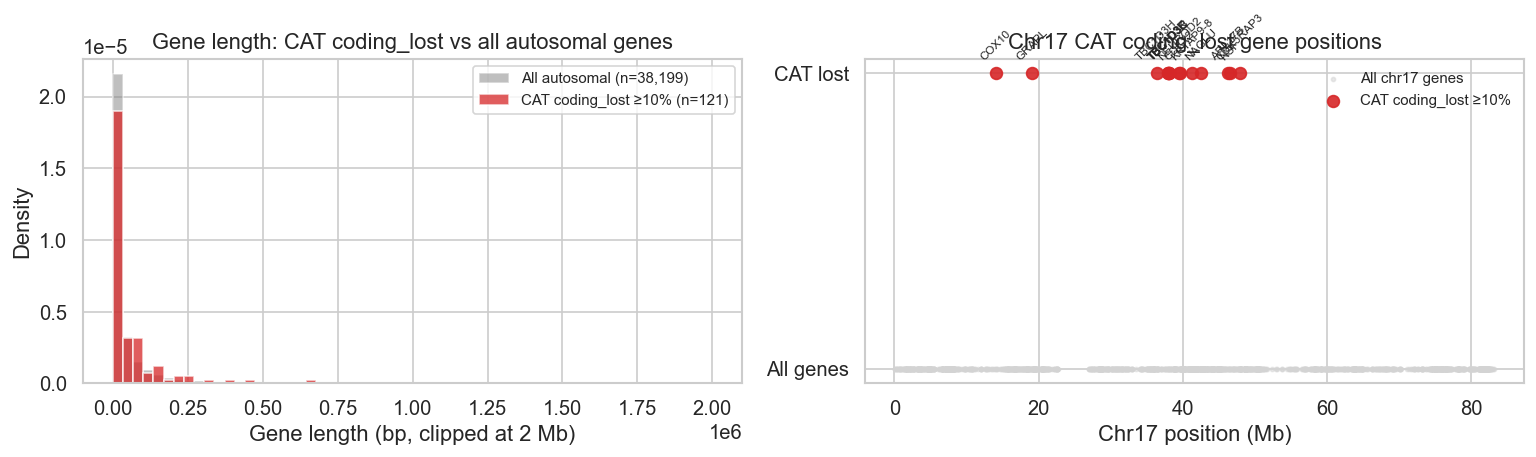

In [26]:
# ── 12c. Metric parity validation + structural characterisation of CAT coding_lost ──
#
# From compute_grch38_divergence.py lines 138-202:
#   load_gene_models_gff() is called identically for both Ensembl and CAT GFF3s.
#   is_coding = cds_length > 0  (sum of CDS feature spans).
#   coding_lost fires when reference['is_coding'] and not projected['is_coding'].
#
# The metric IS symmetric. The 46× asymmetry is genuine: CAT GFF3 files omit
# CDS annotations when the homology-based projection cannot transfer the reading
# frame, while Ensembl projection always carries over CDS features from the reference.

#
# Verification: for coding_lost observations, cat_delta_cds_length should be
# strongly negative (= -ref_cds_length), confirming CDS = 0 in CAT GFF3.

# Filter directly from div to avoid dependency on div_coding column state
_div_c = div[(div['is_coding'] == True) & div['gene_name'].notna()]
cat_cl_obs = _div_c[_div_c['cat_cds_change_type'] == 'coding_lost']
ens_cl_obs = _div_c[_div_c['ens_cds_change_type'] == 'coding_lost']

cat_delta = cat_cl_obs['cat_delta_cds_length'].dropna()
ens_delta = ens_cl_obs['ens_delta_cds_length'].dropna()

print('=== Metric parity validation ===')
print(f'CAT coding_lost observations: {len(cat_cl_obs):,}')
print(f'  cat_delta_cds_length: median={cat_delta.median():.0f}  '
      f'mean={cat_delta.mean():.0f}  pct < -100: {(cat_delta < -100).mean()*100:.1f}%')
print(f'  → Strongly negative delta confirms CDS = 0 in CAT GFF3 (full dropout, not truncation)')
print(f'\nEnsembl coding_lost observations: {len(ens_cl_obs):,}')
print(f'  ens_delta_cds_length: median={ens_delta.median():.0f}  mean={ens_delta.mean():.0f}')
print('\nConclusion: metric defined identically for both annotators. Asymmetry is real.')

# ── Structural features of CAT coding_lost genes ───────────────────────────────
_auto_cs = [str(i) for i in range(1, 23)]
cat_lost_struct = cat_lost.assign(
    gene_length=lambda d: (d['end'] - d['start']).abs()
).dropna(subset=['start', 'end'])
all_gene_len = s1g.assign(
    gene_length=lambda d: (d['end'] - d['start']).abs()
).dropna(subset=['start', 'end'])

lost_auto_s = cat_lost_struct[cat_lost_struct['chrom'].astype(str).isin(_auto_cs)]
all_auto_s  = all_gene_len[all_gene_len['chrom'].astype(str).isin(_auto_cs)]

print(f'\n=== Structural features: CAT coding_lost autosomal genes (n={len(lost_auto_s):,}) ===')
print(f'Gene length: CAT-lost median {lost_auto_s["gene_length"].median()/1e3:.0f} kb  '
      f'vs all autosomal {all_auto_s["gene_length"].median()/1e3:.0f} kb')

# Chr17 drill-down
chr17_lost = (cat_lost_struct[cat_lost_struct['chrom'].astype(str) == '17']
              .sort_values('pct_cat_coding_lost', ascending=False))
print(f'\nChr17 CAT coding_lost genes (n={len(chr17_lost):,}):')
show_17 = [c for c in ['gene_name', 'pct_cat_coding_lost', 'pct_ens_coding_lost',
                        'n_assemblies_assessed', 'start', 'end'] if c in chr17_lost.columns]
display(chr17_lost[show_17].reset_index(drop=True))

# Uniformity: are all assemblies failing or just some?
top_cl_genes = cat_lost.nlargest(10, 'pct_cat_coding_lost')['gene_name'].tolist()
uniformity = (
    _div_c[
        _div_c['gene_name'].isin(top_cl_genes) & (_div_c['cat_cds_change_type'] == 'coding_lost')
    ]
    .groupby('gene_name')['assembly_accession'].nunique()
    .reset_index(name='n_assemblies_failing')
    .merge(cat_lost[['gene_name', 'n_assemblies_assessed', 'pct_cat_coding_lost']].drop_duplicates(),
           on='gene_name', how='left')
    .sort_values('pct_cat_coding_lost', ascending=False)
)
print('\nUniformity of failure across assemblies (top 10 genes):')
display(uniformity.reset_index(drop=True))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bins = np.linspace(0, 2e6, 60)
ax.hist(all_auto_s['gene_length'].clip(0, 2e6), bins=bins, alpha=0.5,
        color='grey', density=True, label=f'All autosomal (n={len(all_auto_s):,})')
ax.hist(lost_auto_s['gene_length'].clip(0, 2e6), bins=bins, alpha=0.75,
        color='#d62728', density=True, label=f'CAT coding_lost ≥10% (n={len(lost_auto_s):,})')
ax.set_xlabel('Gene length (bp, clipped at 2 Mb)'); ax.set_ylabel('Density')
ax.set_title('Gene length: CAT coding_lost vs all autosomal genes')
ax.legend(fontsize=9)

ax = axes[1]
chr17_all_s = all_auto_s[all_auto_s['chrom'].astype(str) == '17'].sort_values('start')
ax.scatter(chr17_all_s['start'] / 1e6, np.zeros(len(chr17_all_s)),
           c='lightgrey', s=6, alpha=0.5, label='All chr17 genes')
ax.scatter(chr17_lost['start'] / 1e6, np.ones(len(chr17_lost)),
           c='#d62728', s=50, alpha=0.9, label='CAT coding_lost ≥10%')
for _, r in chr17_lost.iterrows():
    if pd.notna(r.get('start')):
        ax.annotate(r['gene_name'], (r['start'] / 1e6, 1.0), fontsize=7,
                    xytext=(0, 8), textcoords='offset points', ha='center', rotation=45)
ax.set_xlabel('Chr17 position (Mb)')
ax.set_yticks([0, 1]); ax.set_yticklabels(['All genes', 'CAT lost'])
ax.set_title('Chr17 CAT coding_lost gene positions')
ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'cat_coding_lost_structural.png', bbox_inches='tight')
plt.show()


## 13. Ensembl CDS rescue test

**Hypothesis:** When CAT calls `coding_lost` but Ensembl achieves `exact_match` vs GRCh38, Ensembl may be bridging gaps in the assembly — producing fewer exons than the reference (negative Δ exon count) to rescue the reading frame.

If true: the distribution of `ens_delta_n_exons` for "CAT lost, Ensembl exact" observations should be shifted negative vs "both exact_match" controls.

Observations per scenario:
scenario
both_exact            8172796
other                  299651
cat_lost_ens_exact      20319
both_lost                 879
ens_lost_cat_exact        633


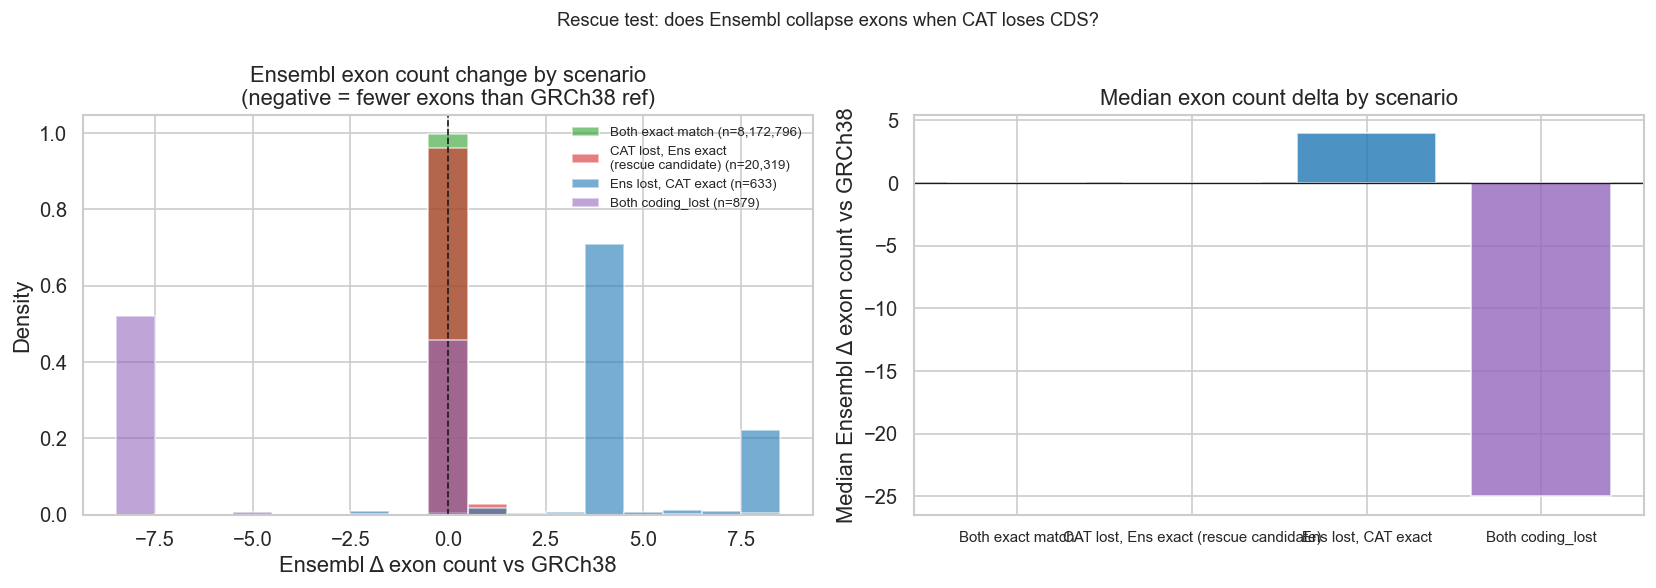


Median ens_delta_n_exons by scenario:
  Both exact match                          median=0.00  mean=0.00  n=8,172,796
  CAT lost, Ens exact
(rescue candidate)    median=0.00  mean=0.02  n=20,319
  Ens lost, CAT exact                       median=4.00  mean=7.27  n=633
  Both coding_lost                          median=-25.00  mean=-13.01  n=879


: 

In [ ]:
# Tag each coding observation by the rescue scenario
# Derive from div_coding (already filtered to is_coding==True, gene_name non-null)
dc = div_coding.dropna(subset=['ens_cds_change_type', 'cat_cds_change_type', 'ens_delta_n_exons']).copy()

dc['scenario'] = 'other'
dc.loc[(dc['ens_cds_change_type'] == 'exact_match') &
       (dc['cat_cds_change_type'] == 'coding_lost'),  'scenario'] = 'cat_lost_ens_exact'
dc.loc[(dc['ens_cds_change_type'] == 'exact_match') &
       (dc['cat_cds_change_type'] == 'exact_match'),  'scenario'] = 'both_exact'
dc.loc[(dc['ens_cds_change_type'] == 'coding_lost') &
       (dc['cat_cds_change_type'] == 'coding_lost'),  'scenario'] = 'both_lost'
dc.loc[(dc['ens_cds_change_type'] == 'coding_lost') &
       (dc['cat_cds_change_type'] == 'exact_match'),  'scenario'] = 'ens_lost_cat_exact'
       

counts = dc['scenario'].value_counts()
print('Observations per scenario:')
print(counts.to_string())

# Compare ens_delta_n_exons across scenarios
focus = ['both_exact', 'cat_lost_ens_exact', 'ens_lost_cat_exact', 'both_lost']
focus = [s for s in focus if s in dc['scenario'].values]
labels = {
    'both_exact':        'Both exact match',
    'cat_lost_ens_exact':'CAT lost, Ens exact\n(rescue candidate)',
    'ens_lost_cat_exact':'Ens lost, CAT exact',
    'both_lost':         'Both coding_lost',
}
colors = {'both_exact': '#2ca02c', 'cat_lost_ens_exact': '#d62728',
          'ens_lost_cat_exact': '#1f77b4', 'both_lost': '#9467bd'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
clip = (-8, 8)
for sc in focus:
    vals = dc.loc[dc['scenario'] == sc, 'ens_delta_n_exons'].clip(*clip)
    ax.hist(vals, bins=np.arange(clip[0]-0.5, clip[1]+1.5, 1),
            alpha=0.6, label=f"{labels[sc]} (n={counts.get(sc,0):,})",
            color=colors[sc], density=True)
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_xlabel('Ensembl Δ exon count vs GRCh38')
ax.set_ylabel('Density')
ax.set_title('Ensembl exon count change by scenario\n(negative = fewer exons than GRCh38 ref)')
ax.legend(fontsize=8, frameon=False)

ax = axes[1]
medians = {sc: dc.loc[dc['scenario'] == sc, 'ens_delta_n_exons'].median() for sc in focus}
means   = {sc: dc.loc[dc['scenario'] == sc, 'ens_delta_n_exons'].mean()   for sc in focus}
x = np.arange(len(focus))
ax.bar(x, [medians[s] for s in focus], color=[colors[s] for s in focus], alpha=0.8)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([labels[s].replace('\n', ' ') for s in focus], fontsize=9)
ax.set_ylabel('Median Ensembl Δ exon count vs GRCh38')
ax.set_title('Median exon count delta by scenario')

plt.suptitle('Rescue test: does Ensembl collapse exons when CAT loses CDS?', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ensembl_rescue_test.png', bbox_inches='tight')
plt.show()

print('\nMedian ens_delta_n_exons by scenario:')
for sc in focus:
    vals = dc.loc[dc['scenario'] == sc, 'ens_delta_n_exons']
    print(f'  {labels[sc]:40s}  median={vals.median():.2f}  mean={vals.mean():.2f}  n={len(vals):,}')


## 14. Rescue deep dive — what is actually different?

Median `ens_delta_n_exons = 0` for rescue candidates means Ensembl is **not** collapsing exons.  
The exon structure is identical to GRCh38. CAT is failing due to insufficient transcript evidence, not disrupted sequence.

Next questions: which genes are repeatedly rescued? What chromosome are they on? And is there a CDS length signal?

## 14b. Joint exon delta analysis — structural complexity and PAV candidates

Where both annotators independently find a different exon count from GRCh38, that disagreement is signal worth following.  
Neither pipeline is an oracle — both are projections of reference structure onto non-reference assemblies, and both can fail differently at complex loci.

**Quadrant logic:**
- Both expanded / both contracted → convergent signal, strongest candidate for a real structural difference from GRCh38
- One expanded, other unchanged → weaker signal, could be one annotator picking up partial evidence
- Discordant (one up, one down) → both struggling at the same locus, complex region

These are **candidates for further investigation**, not confirmed PAV calls.

Joint exon delta classification (coding genes, both cols non-null):
Total observations with ≥1 non-zero delta: 176,002
  ens_only_expanded             : 63,207
  cat_only_contracted           : 40,575
  cat_only_expanded             : 39,839
  both_expanded                 : 20,597
  both_contracted               : 6,370
  discordant                    : 3,574
  ens_only_contracted           : 1,840


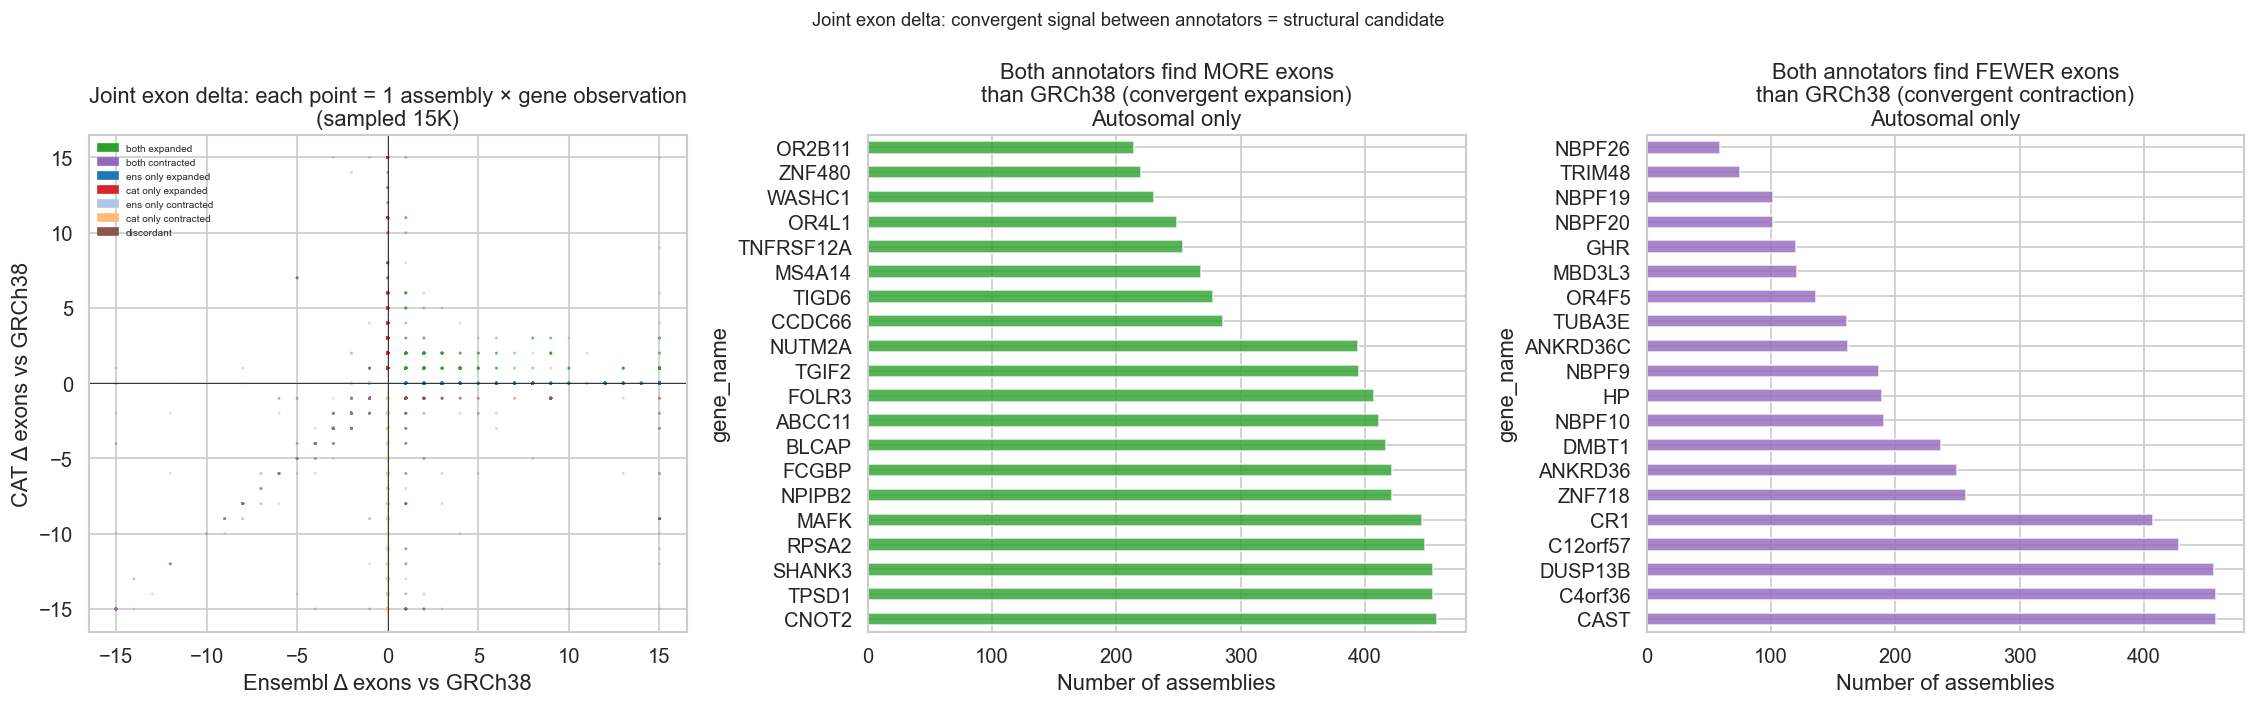


Convergent expansion candidates (≥2 assemblies, autosomal): 729 genes
Top 15:


,gene_name,n_assemblies,median_ens,median_cat,ensembl_biotype,chrom
0,CNOT2,458,1.0,1.0,protein_coding,12
1,TPSD1,455,2.0,2.0,protein_coding,16
2,SHANK3,455,1.0,1.0,protein_coding,22
3,RPSA2,448,4.0,1.0,pseudogene,19
4,MAFK,446,1.0,1.0,protein_coding,7
5,NPIPB2,422,1.0,1.0,protein_coding,16
6,FCGBP,422,69.0,1.0,protein_coding,19
7,BLCAP,417,1.0,1.0,protein_coding,20
8,ABCC11,411,1.0,1.0,protein_coding,16
9,FOLR3,407,1.0,1.0,protein_coding,11



Convergent contraction candidates (≥2 assemblies, autosomal): 149 genes
Top 15:


,gene_name,n_assemblies,median_ens,median_cat,ensembl_biotype,chrom
0,CAST,458,-25.0,-25.0,lncRNA,5
1,C4orf36,458,-2.0,-2.0,protein_coding,4
2,DUSP13B,456,-3.0,-3.0,protein_coding,10
3,C12orf57,428,-1.0,-1.0,protein_coding,12
4,CR1,407,-8.0,-8.0,protein_coding,1
5,ZNF718,257,-2.0,-2.0,protein_coding,4
6,ANKRD36,250,-2.0,-2.0,protein_coding,2
7,DMBT1,237,-6.0,-6.0,protein_coding,10
8,NBPF10,191,-6.0,-6.0,protein_coding,1
9,HP,189,-3.0,-2.0,protein_coding,16



Genes with discordant exon deltas (annotators disagree on direction): 258
Top 15:


,gene_name,n_assemblies,ensembl_biotype,chrom
0,POLR2A,458,protein_coding,17
1,SLC37A4,458,protein_coding,11
2,SPINK14,233,protein_coding,5
3,DMBT1,171,protein_coding,10
4,NBPF1,159,protein_coding,1
5,NPIPB6,105,protein_coding,16
6,GOLGA6C,98,protein_coding,15
7,PRR20A,94,protein_coding,13
8,NBPF8,92,protein_coding,1
9,RHOH,83,protein_coding,4


: 

In [ ]:
auto_chroms_str = [str(i) for i in range(1, 23)]

# Work from div_coding (already filtered to is_coding==True, gene_name non-null)
coding_delta = div_coding[
    div_coding['ens_delta_n_exons'].notna() &
    div_coding['cat_delta_n_exons'].notna()
].copy()

# Classify each observation by joint direction
def delta_class(e, c):
    if e > 0 and c > 0:  return 'both_expanded'
    if e < 0 and c < 0:  return 'both_contracted'
    if e > 0 and c == 0: return 'ens_only_expanded'
    if e == 0 and c > 0: return 'cat_only_expanded'
    if e < 0 and c == 0: return 'ens_only_contracted'
    if e == 0 and c < 0: return 'cat_only_contracted'
    if e == 0 and c == 0: return 'both_unchanged'
    return 'discordant'  # opposite signs

coding_delta['dclass'] = coding_delta.apply(
    lambda r: delta_class(r['ens_delta_n_exons'], r['cat_delta_n_exons']), axis=1)

nonzero = coding_delta[coding_delta['dclass'] != 'both_unchanged']
print('Joint exon delta classification (coding genes, both cols non-null):')
print(f'Total observations with ≥1 non-zero delta: {len(nonzero):,}')
vc = nonzero['dclass'].value_counts()
for k, v in vc.items():
    print(f'  {k:30s}: {v:,}')

# ── Plot 1: 2D scatter ──────────────────────────────────────────────────────
clip = 15
sample = nonzero.sample(min(15000, len(nonzero)), random_state=42)

quad_colors = {
    'both_expanded':      '#2ca02c',
    'both_contracted':    '#9467bd',
    'ens_only_expanded':  '#1f77b4',
    'cat_only_expanded':  '#d62728',
    'ens_only_contracted':'#aec7e8',
    'cat_only_contracted':'#ffbb78',
    'discordant':         '#8c564b',
}
sample_c = [quad_colors.get(d, '#aaaaaa') for d in sample['dclass']]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

ax = axes[0]
ax.scatter(sample['ens_delta_n_exons'].clip(-clip, clip),
           sample['cat_delta_n_exons'].clip(-clip, clip),
           c=sample_c, s=3, alpha=0.25, linewidths=0)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Ensembl Δ exons vs GRCh38')
ax.set_ylabel('CAT Δ exons vs GRCh38')
ax.set_title('Joint exon delta: each point = 1 assembly × gene observation\n(sampled 15K)')
handles = [mpatches.Patch(color=v, label=k.replace('_',' ')) for k, v in quad_colors.items()]
ax.legend(handles=handles, fontsize=6, frameon=False, loc='upper left')

# ── Plot 2: top both_expanded genes (convergent expansion candidates) ────────
ax = axes[1]
both_exp = (nonzero[nonzero['dclass'] == 'both_expanded']
            .groupby('gene_name').agg(
                n_assemblies=('assembly_accession', 'count'),
                median_ens=('ens_delta_n_exons', 'median'),
                median_cat=('cat_delta_n_exons', 'median'),
            ).reset_index()
            .merge(s1g[['gene_name','ensembl_biotype','chrom']].drop_duplicates(), on='gene_name', how='left')
            .loc[lambda d: d["chrom"].astype(str).isin(auto_chroms_str)]
            .sort_values('n_assemblies', ascending=False))
both_exp.head(20).plot.barh(x='gene_name', y='n_assemblies', ax=ax,
                             color='#2ca02c', alpha=0.8, legend=False)
ax.set_xlabel('Number of assemblies')
ax.set_title('Both annotators find MORE exons\nthan GRCh38 (convergent expansion)\nAutosomal only')

# ── Plot 3: top both_contracted genes ────────────────────────────────────────
ax = axes[2]
both_con = (nonzero[nonzero['dclass'] == 'both_contracted']
            .groupby('gene_name').agg(
                n_assemblies=('assembly_accession', 'count'),
                median_ens=('ens_delta_n_exons', 'median'),
                median_cat=('cat_delta_n_exons', 'median'),
            ).reset_index()
            .merge(s1g[['gene_name','ensembl_biotype','chrom']].drop_duplicates(), on='gene_name', how='left')
            .loc[lambda d: d["chrom"].astype(str).isin(auto_chroms_str)]
            .sort_values('n_assemblies', ascending=False))
both_con.head(20).plot.barh(x='gene_name', y='n_assemblies', ax=ax,
                             color='#9467bd', alpha=0.8, legend=False)
ax.set_xlabel('Number of assemblies')
ax.set_title('Both annotators find FEWER exons\nthan GRCh38 (convergent contraction)\nAutosomal only')

plt.suptitle('Joint exon delta: convergent signal between annotators = structural candidate', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'joint_exon_delta.png', bbox_inches='tight')
plt.show()

# ── Full candidate tables ─────────────────────────────────────────────────────
print(f'\nConvergent expansion candidates (≥2 assemblies, autosomal): {(both_exp["n_assemblies"] >= 2).sum():,} genes')
print('Top 15:')
display(both_exp.head(15).reset_index(drop=True))

print(f'\nConvergent contraction candidates (≥2 assemblies, autosomal): {(both_con["n_assemblies"] >= 2).sum():,} genes')
print('Top 15:')
display(both_con.head(15).reset_index(drop=True))

discord = (nonzero[nonzero['dclass'] == 'discordant']
           .groupby('gene_name').size().reset_index(name='n_assemblies')
           .merge(s1g[['gene_name','ensembl_biotype','chrom']].drop_duplicates(), on='gene_name', how='left')
           .loc[lambda d: d["chrom"].astype(str).isin(auto_chroms_str)]
           .sort_values('n_assemblies', ascending=False))
print(f'\nGenes with discordant exon deltas (annotators disagree on direction): {len(discord):,}')
print('Top 15:')
display(discord.head(15).reset_index(drop=True))


## 14c. POLR2A — exon count discordant across all 458 assemblies

POLR2A (RNA Pol II largest subunit) is classified as `discordant` in every assembly: one annotator finds more exons than GRCh38, the other fewer.

**Key diagnostic**: if `ens_delta_n_exons` and `cat_delta_n_exons` each take only 1–2 distinct values across all 458 assemblies, the discordance is assembly-independent — a systematic projection artefact from the GRCh38 reference model (e.g. one pipeline includes an alternative exon the other doesn't). If the deltas are variable, it may be genuine structural variation at this locus.

POLR2A observations: 458  (expected ~458, 1 per assembly)

Ensembl Δ exons: median=1.0  min=1  max=3  n_unique_values=2
CAT Δ exons:     median=-1.0  min=-28  max=-1  n_unique_values=2

Joint delta class breakdown:
dclass
discordant    458

CDS length deltas:
  Ensembl Δ CDS: median=-3
  CAT Δ CDS:     median=0

Ensembl Δ exon value distribution: {1.0: 457, 3.0: 1}
CAT Δ exon value distribution:     {-1.0: 457, -28.0: 1}

→ NEAR-UNIFORM DELTA: discordance is assembly-independent.
  Both annotators project consistent models that differ from each other vs GRCh38.
  Likely a specific isoform or alternative exon that one pipeline includes and the other does not.
  This is a GRCh38 reference projection issue, not structural variation in the assemblies.


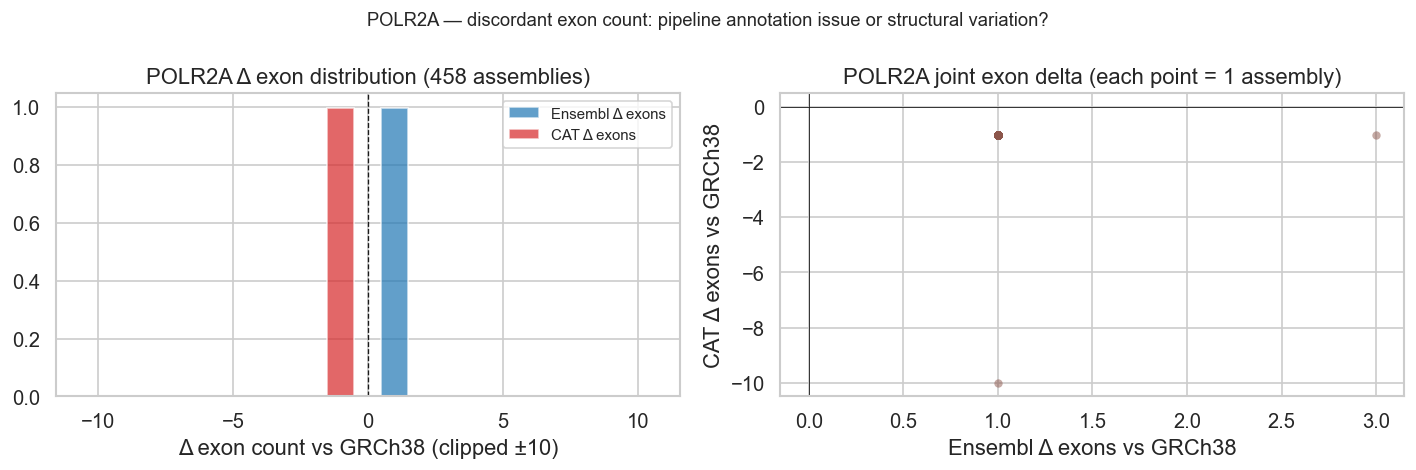

: 

In [ ]:
# ── 14c. POLR2A — systematic exon count discordance across all assemblies ──────
polr2a = coding_delta[coding_delta['gene_name'] == 'POLR2A'].copy()
print(f'POLR2A observations: {len(polr2a):,}  (expected ~458, 1 per assembly)')

print(f'\nEnsembl Δ exons: median={polr2a["ens_delta_n_exons"].median():.1f}  '
      f'min={polr2a["ens_delta_n_exons"].min():.0f}  max={polr2a["ens_delta_n_exons"].max():.0f}  '
      f'n_unique_values={polr2a["ens_delta_n_exons"].nunique()}')
print(f'CAT Δ exons:     median={polr2a["cat_delta_n_exons"].median():.1f}  '
      f'min={polr2a["cat_delta_n_exons"].min():.0f}  max={polr2a["cat_delta_n_exons"].max():.0f}  '
      f'n_unique_values={polr2a["cat_delta_n_exons"].nunique()}')

print(f'\nJoint delta class breakdown:')
print(polr2a['dclass'].value_counts().to_string())

print(f'\nCDS length deltas:')
print(f'  Ensembl Δ CDS: median={polr2a["ens_delta_cds_length"].median():.0f}')
print(f'  CAT Δ CDS:     median={polr2a["cat_delta_cds_length"].median():.0f}')

print(f'\nEnsembl Δ exon value distribution: {polr2a["ens_delta_n_exons"].value_counts().head(5).to_dict()}')
print(f'CAT Δ exon value distribution:     {polr2a["cat_delta_n_exons"].value_counts().head(5).to_dict()}')

# Diagnostic: uniform delta = assembly-independent annotation issue
ens_u = polr2a['ens_delta_n_exons'].nunique()
cat_u = polr2a['cat_delta_n_exons'].nunique()
if ens_u <= 3 and cat_u <= 3:
    print('\n→ NEAR-UNIFORM DELTA: discordance is assembly-independent.')
    print('  Both annotators project consistent models that differ from each other vs GRCh38.')
    print('  Likely a specific isoform or alternative exon that one pipeline includes and the other does not.')
    print('  This is a GRCh38 reference projection issue, not structural variation in the assemblies.')
else:
    print(f'\n→ VARIABLE DELTA (ens n_unique={ens_u}, cat n_unique={cat_u}): '
          'discordance varies across assemblies.')
    print('  May reflect assembly-specific structural variation at the POLR2A locus.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
clip = 10
bins = np.arange(-clip - 0.5, clip + 1.5, 1)
ax.hist(polr2a['ens_delta_n_exons'].clip(-clip, clip), bins=bins, alpha=0.7,
        color='#1f77b4', label='Ensembl Δ exons', density=True)
ax.hist(polr2a['cat_delta_n_exons'].clip(-clip, clip), bins=bins, alpha=0.7,
        color='#d62728', label='CAT Δ exons', density=True)
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Δ exon count vs GRCh38 (clipped ±10)')
ax.set_title(f'POLR2A Δ exon distribution ({len(polr2a):,} assemblies)')
ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(polr2a['ens_delta_n_exons'].clip(-clip, clip),
           polr2a['cat_delta_n_exons'].clip(-clip, clip),
           s=25, alpha=0.5, color='#8c564b', linewidths=0)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Ensembl Δ exons vs GRCh38'); ax.set_ylabel('CAT Δ exons vs GRCh38')
ax.set_title('POLR2A joint exon delta (each point = 1 assembly)')

plt.suptitle('POLR2A — discordant exon count: pipeline annotation issue or structural variation?',
             fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'polr2a_exon_delta.png', bbox_inches='tight')
plt.show()


CAT loses, Ensembl exact:
  Total observations: 20,319  |  Unique genes: 666
  Autosomal genes: 605  |  Genes in ≥50 assemblies: 93
Ensembl loses, CAT exact:
  Total observations: 633  |  Unique genes: 96
  Autosomal genes: 94  |  Genes in ≥50 assemblies: 1


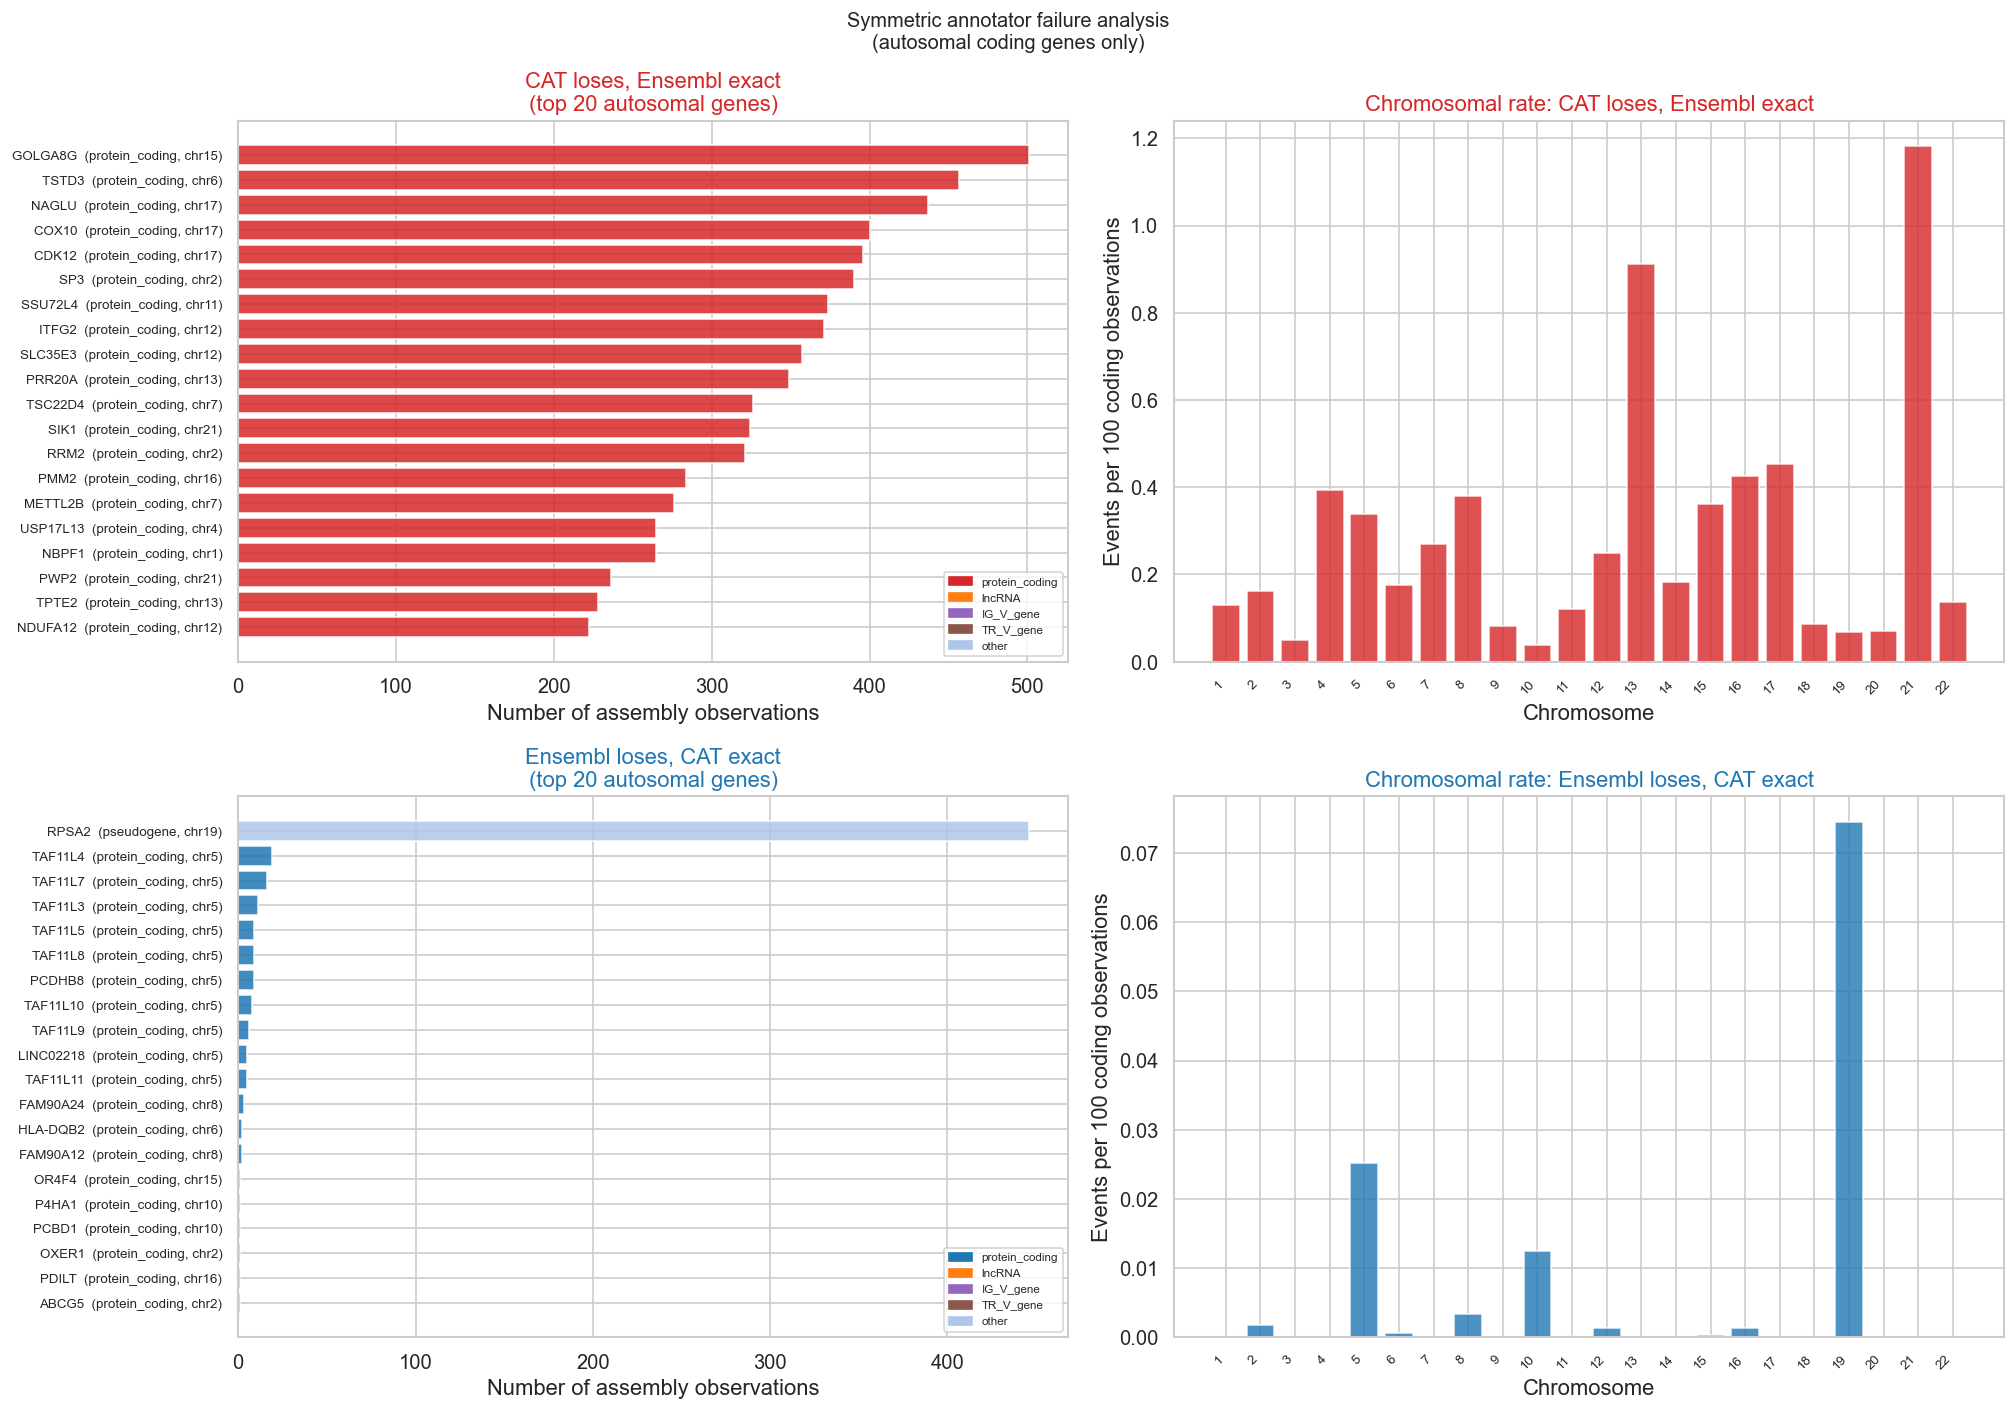


CAT loses, Ensembl exact — top 20 autosomal genes:


,gene_name,n_assemblies,ensembl_biotype,chrom
0,GOLGA8G,501,protein_coding,15
1,TSTD3,457,protein_coding,6
2,NAGLU,437,protein_coding,17
3,COX10,400,protein_coding,17
4,CDK12,396,protein_coding,17
5,SP3,390,protein_coding,2
6,SSU72L4,374,protein_coding,11
7,ITFG2,371,protein_coding,12
8,SLC35E3,357,protein_coding,12
9,PRR20A,349,protein_coding,13



Ensembl loses, CAT exact — top 20 autosomal genes:


,gene_name,n_assemblies,ensembl_biotype,chrom
0,RPSA2,446,pseudogene,19
1,TAF11L4,19,protein_coding,5
2,TAF11L7,16,protein_coding,5
3,TAF11L3,11,protein_coding,5
4,TAF11L5,9,protein_coding,5
5,TAF11L8,9,protein_coding,5
6,PCDHB8,9,protein_coding,5
7,TAF11L10,8,protein_coding,5
8,TAF11L9,6,protein_coding,5
9,LINC02218,5,protein_coding,5


: 

In [ ]:
scenarios = [
    ('cat_lost_ens_exact', 'CAT loses, Ensembl exact', '#d62728'),
    ('ens_lost_cat_exact', 'Ensembl loses, CAT exact', '#1f77b4'),
]

auto_chroms_str = [str(i) for i in range(1, 23)]
autosome_set = set(s1g[s1g['chrom'].astype(str).isin(auto_chroms_str)]['gene_name'])

# Print summary for both directions
for scenario, label, color in scenarios:
    sg = dc[dc['scenario'] == scenario]
    auto = sg[sg['gene_name'].isin(autosome_set)]
    print(f'{label}:')
    print(f'  Total observations: {len(sg):,}  |  Unique genes: {sg["gene_name"].nunique():,}')
    print(f'  Autosomal genes: {auto["gene_name"].nunique():,}  |  '
          f'Genes in ≥50 assemblies: {(auto.groupby("gene_name").size() >= 50).sum():,}')

fig, axes = plt.subplots(2, 2, figsize=(17, 12))

for row_idx, (scenario, title, color) in enumerate(scenarios):
    by_gene = (dc[dc['scenario'] == scenario]
               .groupby('gene_name').size().reset_index(name='n_assemblies')
               .merge(s1g[['gene_name','ensembl_biotype','chrom']].drop_duplicates(), on='gene_name', how='left'))
    by_gene_auto = (by_gene[by_gene['chrom'].astype(str).isin(auto_chroms_str)]
                    .sort_values('n_assemblies', ascending=False))

    # ── Top genes barplot ──
    ax = axes[row_idx, 0]
    top20 = by_gene_auto.head(20).sort_values('n_assemblies')
    bt_pal = {'protein_coding': color, 'lncRNA': '#ff7f0e',
              'IG_V_gene': '#9467bd', 'TR_V_gene': '#8c564b'}
    bar_c = [bt_pal.get(bt, '#aec7e8') for bt in top20['ensembl_biotype']]
    ax.barh(range(len(top20)), top20['n_assemblies'], color=bar_c, alpha=0.85)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(
        [f"{r.gene_name}  ({r.ensembl_biotype}, chr{str(r.chrom).replace('nan','?')})"
         for r in top20.itertuples()], fontsize=8)
    ax.set_xlabel('Number of assembly observations')
    ax.set_title(f'{title}\n(top 20 autosomal genes)', color=color)
    handles = [mpatches.Patch(color=c, label=bt) for bt, c in bt_pal.items()]
    handles.append(mpatches.Patch(color='#aec7e8', label='other'))
    ax.legend(handles=handles, fontsize=7, loc='lower right')

    # ── Chromosomal rate ──
    ax = axes[row_idx, 1]
    total_by_chrom = (dc.merge(s1g[['gene_name','chrom']].drop_duplicates(), on='gene_name', how='left')
                      .dropna(subset=['chrom'])
                      .assign(chrom=lambda d: d['chrom'].astype(str))
                      .groupby('chrom').size().reindex(auto_chroms_str).fillna(1))
    event_by_chrom = (dc[dc['scenario'] == scenario]
                      .merge(s1g[['gene_name','chrom']].drop_duplicates(), on='gene_name', how='left')
                      .dropna(subset=['chrom'])
                      .assign(chrom=lambda d: d['chrom'].astype(str))
                      .groupby('chrom').size().reindex(auto_chroms_str).fillna(0))
    rate = (event_by_chrom / total_by_chrom * 100).fillna(0)
    ax.bar(range(len(rate)), rate.values, color=color, alpha=0.8)
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, fontsize=8, rotation=45, ha='right')
    ax.set_xlabel('Chromosome')
    ax.set_ylabel('Events per 100 coding observations')
    ax.set_title(f'Chromosomal rate: {title}', color=color)

plt.suptitle('Symmetric annotator failure analysis\n(autosomal coding genes only)', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rescue_symmetric.png', bbox_inches='tight')
plt.show()

# Tables for both
for scenario, label, color in scenarios:
    by_gene = (dc[dc['scenario'] == scenario]
               .groupby('gene_name').size().reset_index(name='n_assemblies')
               .merge(s1g[['gene_name','ensembl_biotype','chrom']].drop_duplicates(), on='gene_name', how='left'))
    by_gene_auto = by_gene[by_gene['chrom'].astype(str).isin(auto_chroms_str)].sort_values('n_assemblies', ascending=False)
    print(f'\n{label} — top 20 autosomal genes:')
    display(by_gene_auto.head(20).reset_index(drop=True))

## 15. Dimensionality reduction: Assembly landscape

Build a gene × assembly divergence matrix. Each assembly becomes a point in 40K-dimensional gene space.  
UMAP collapses this to 2D — assemblies with similar annotation profiles cluster together.

Encoding: `both_agree_reference`=2, `both_agree_diverged`=1, `insufficient_data`=0, `ensembl_specific`=−1, `cat_specific`=−2, absent=0

Pivot: (458, 40821)  (7.6s)
PCA: 38.5% variance  (0.2s)
Assembly UMAP done  (5.9s)


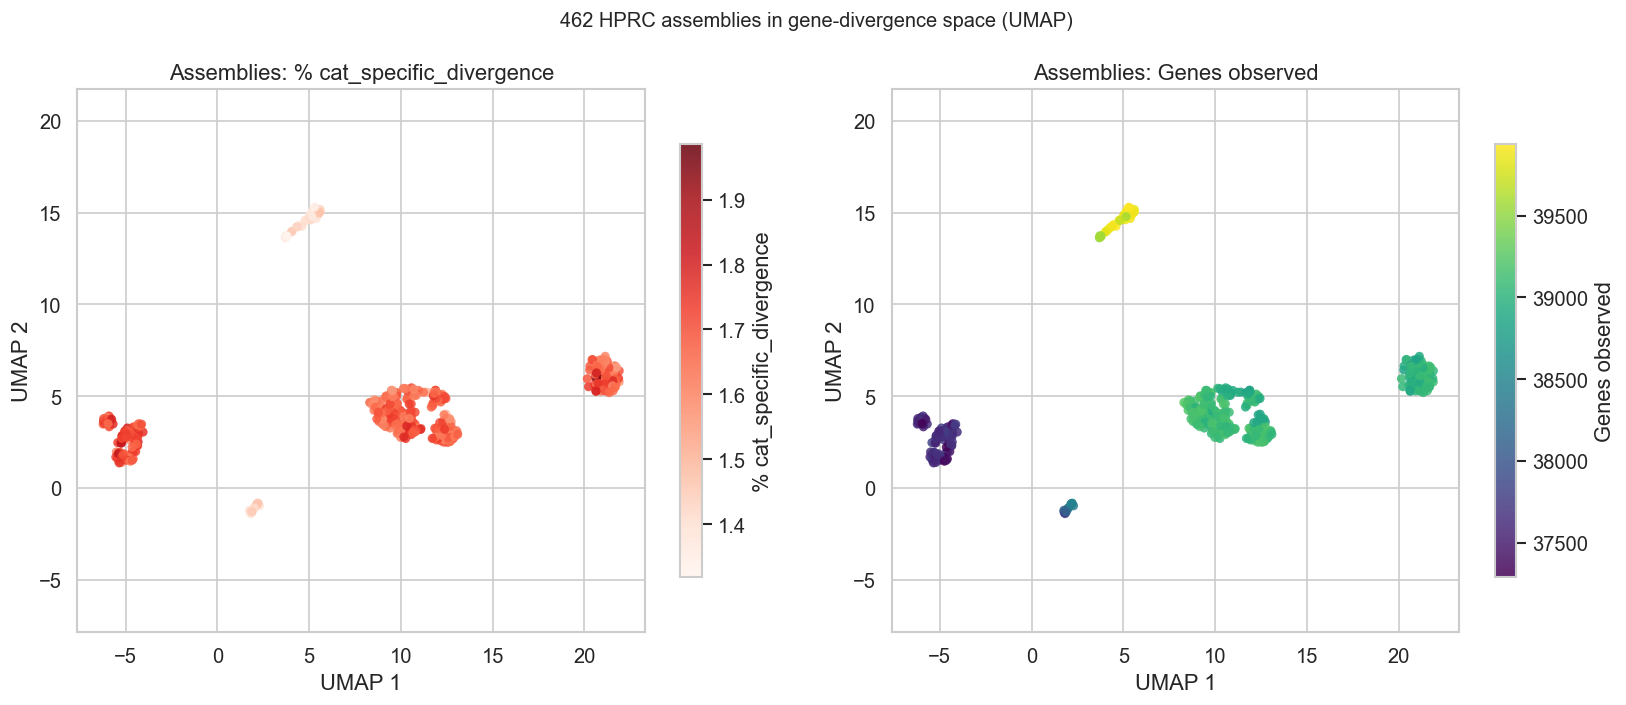

: 

In [ ]:
import umap.umap_ as umap_
from sklearn.decomposition import PCA
import time

CAT_ENCODE = {
    'both_agree_reference':        2.0,
    'both_agree_diverged':         1.0,
    'insufficient_data':           0.0,
    'ensembl_specific_divergence': -1.0,
    'cat_specific_divergence':     -2.0,
}

# ── Build pivot matrix (fast: drop_duplicates instead of groupby+mode) ──
t0 = time.time()
div_dedup = (div.dropna(subset=['gene_name', 'divergence_category'])
             [['assembly_accession', 'gene_name', 'divergence_category']]
             .drop_duplicates(['assembly_accession', 'gene_name']))  # first occurrence per pair
div_dedup['div_val'] = div_dedup['divergence_category'].map(CAT_ENCODE)

piv = (div_dedup.pivot(index='assembly_accession', columns='gene_name', values='div_val')
       .fillna(0).astype('float32'))
print(f'Pivot: {piv.shape}  ({time.time()-t0:.1f}s)')

# ── PCA → UMAP on assemblies (462 points) ──
t0 = time.time()
pca = PCA(n_components=50, random_state=42)
pca_coords = pca.fit_transform(piv.values)
print(f'PCA: {pca.explained_variance_ratio_.sum()*100:.1f}% variance  ({time.time()-t0:.1f}s)')

t0 = time.time()
reducer_assm = umap_.UMAP(n_components=2, random_state=42, n_neighbors=20,
                           min_dist=0.2, metric='euclidean')
assm_emb = reducer_assm.fit_transform(pca_coords)
print(f'Assembly UMAP done  ({time.time()-t0:.1f}s)')

# Per-assembly summary stats for colouring
assm_meta = (div_dedup.groupby('assembly_accession').agg(
    pct_cat_div=('divergence_category',
                 lambda x: (x == 'cat_specific_divergence').mean() * 100),
    pct_ref=('divergence_category',
             lambda x: (x == 'both_agree_reference').mean() * 100),
    n_genes=('gene_name', 'count'),
).reset_index())

emb_df = (pd.DataFrame(assm_emb, columns=['UMAP1','UMAP2'], index=piv.index)
          .reset_index()
          .merge(assm_meta, on='assembly_accession', how='left'))

del div_dedup  # pivot + assm_meta are built; free the intermediate

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, label, cmap in [
    (axes[0], 'pct_cat_div', '% cat_specific_divergence', 'Reds'),
    (axes[1], 'n_genes',     'Genes observed',             'viridis'),
]:
    sc = ax.scatter(emb_df['UMAP1'], emb_df['UMAP2'],
                    c=emb_df[col], cmap=cmap, s=30, alpha=0.85, linewidths=0)
    plt.colorbar(sc, ax=ax, label=label, shrink=0.8)
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
    ax.set_title(f'Assemblies: {label}')
    ax.set_aspect('equal', adjustable='datalim')

plt.suptitle('462 HPRC assemblies in gene-divergence space (UMAP)', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'assembly_umap.png', bbox_inches='tight')
plt.show()


## 15b. UMAP cluster diagnosis

K-means cluster the assembly UMAP and identify which genes most differentiate each cluster.  
Also infer XX vs XY haplotypes from Y-chromosome gene presence.

Y-linked genes in pivot: 417
X-linked genes in pivot: 1878

Inferred has-Y assemblies: 113 / 458  (24.7%)


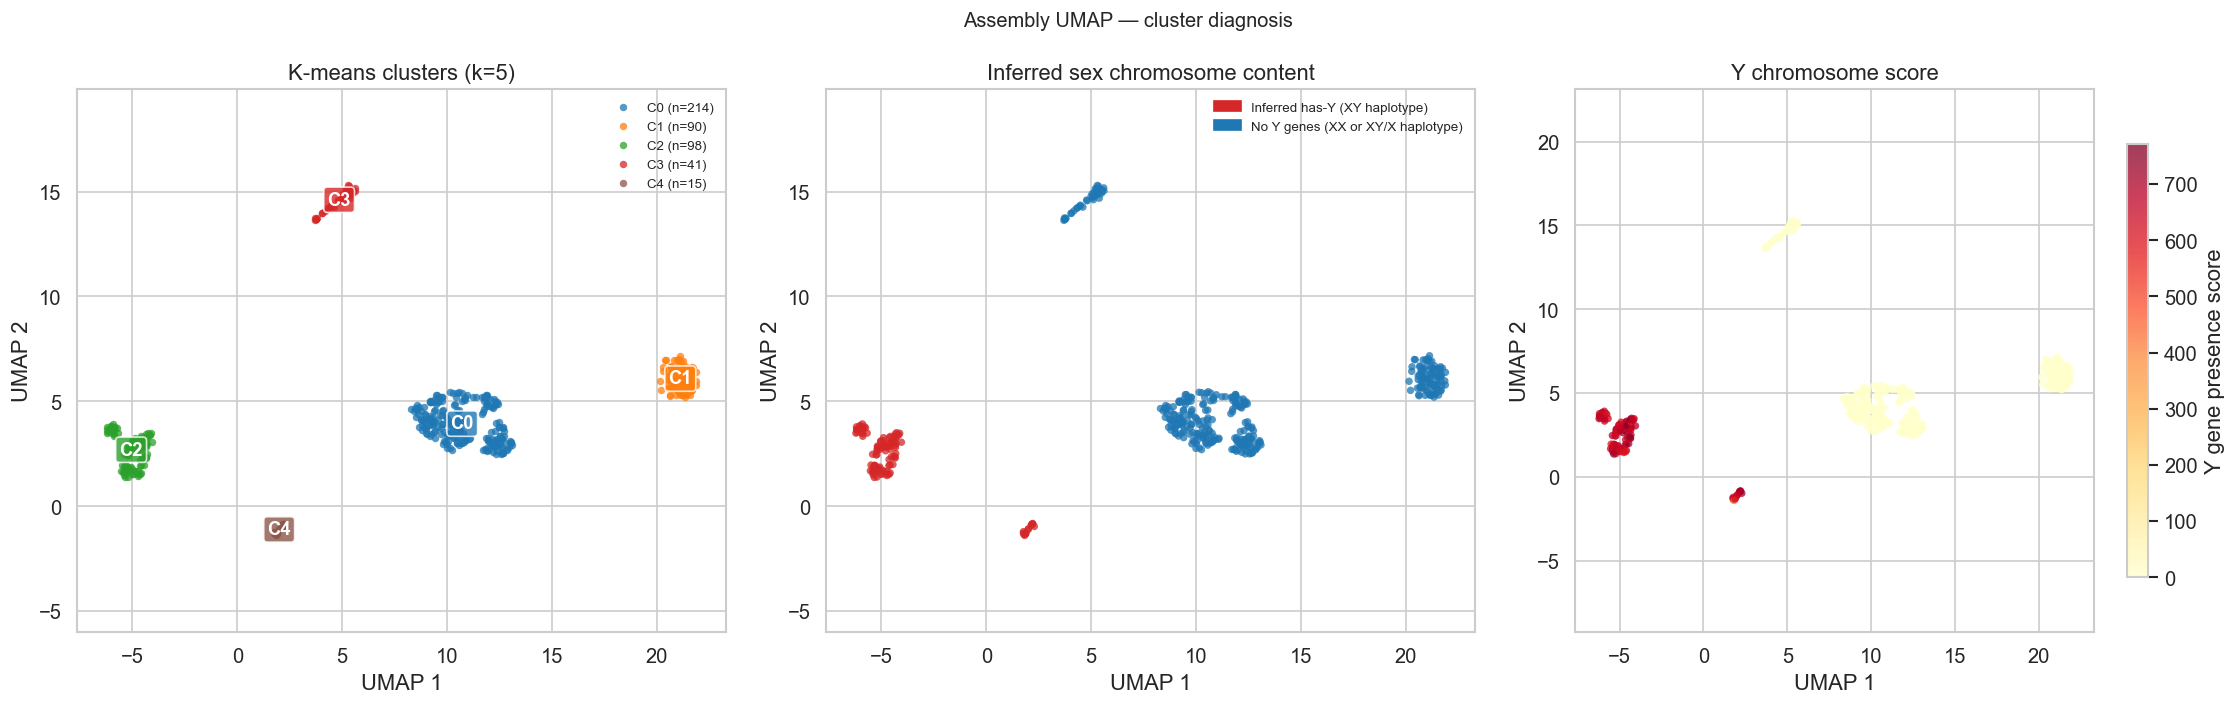


Cluster summary:


,n_assemblies,pct_has_y,mean_pct_cat_div,mean_n_genes
cluster,,,,
0,214,0.0,1.66,39079.03
1,90,0.0,1.66,39017.47
2,98,100.0,1.71,37622.88
3,41,0.0,1.40,39825.49
4,15,100.0,1.42,38297.67



Top 10 genes most characteristic of each cluster (highest |cluster mean − grand mean|):

Cluster C0 (n=214 assemblies, 0% has-Y):
  USP26                 chrX    protein_coding             ▲ more reference
  RN7SKP48              chr4    misc_RNA                   ▼ more diverged
  FSIP2LP               chrX    transcribed_unprocessed_pseudogene  ▲ more reference
  RNU6-648P             chrX    snRNA                      ▲ more reference
  NHS-AS1               chrX    lncRNA                     ▲ more reference
  CNGA2                 chrX    protein_coding             ▲ more reference
  GPC3                  chrX    protein_coding             ▲ more reference
  LINC00189             chr21   lncRNA                     ▼ more diverged
  SRPK3                 chrX    protein_coding             ▲ more reference
  CA5BP1                chrX    transcribed_unprocessed_pseudogene  ▲ more reference

Cluster C1 (n=90 assemblies, 0% has-Y):
  EFCAB15P              chr17   transcribed_unitary_

: 

In [ ]:
from sklearn.cluster import KMeans

# ── Infer XX vs XY from Y-gene presence in piv ──────────────────────────────
y_genes_in_piv = [g for g in s1g[s1g['chrom'].astype(str) == 'Y']['gene_name'] if g in piv.columns]
x_genes_in_piv = [g for g in s1g[s1g['chrom'].astype(str) == 'X']['gene_name'] if g in piv.columns]
print(f'Y-linked genes in pivot: {len(y_genes_in_piv)}')
print(f'X-linked genes in pivot: {len(x_genes_in_piv)}')

# Score each assembly: sum of Y-gene presence values (positive = Y present)
y_score = piv[y_genes_in_piv].clip(lower=0).sum(axis=1)
x_score = piv[x_genes_in_piv].clip(lower=0).sum(axis=1)
# Assemblies above median Y score likely carry a Y chromosome
y_thresh = y_score.quantile(0.4)   # ~40th pct splits XY-hap from XX cleanly
has_y = y_score > y_thresh
emb_df['has_y'] = emb_df['assembly_accession'].map(has_y)
emb_df['y_score'] = emb_df['assembly_accession'].map(y_score)
emb_df['x_score'] = emb_df['assembly_accession'].map(x_score)
print(f'\nInferred has-Y assemblies: {has_y.sum():,} / {len(has_y):,}  '
      f'({has_y.mean()*100:.1f}%)')

# ── K-means on UMAP coords to label clusters ─────────────────────────────────
N_CLUST = 5
km = KMeans(n_clusters=N_CLUST, random_state=42, n_init=20)
emb_df['cluster'] = km.fit_predict(emb_df[['UMAP1', 'UMAP2']])
cluster_pal = plt.cm.tab10(np.linspace(0, 0.5, N_CLUST))

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# Plot 1: K-means clusters + centroid labels
ax = axes[0]
for ci in range(N_CLUST):
    sub = emb_df[emb_df['cluster'] == ci]
    ax.scatter(sub['UMAP1'], sub['UMAP2'], s=20, alpha=0.75,
               color=cluster_pal[ci], label=f'C{ci} (n={len(sub)})', linewidths=0)
    cx, cy = sub[['UMAP1', 'UMAP2']].mean()
    ax.text(cx, cy, f'C{ci}', fontsize=11, fontweight='bold', ha='center', va='center',
            color='white', bbox=dict(boxstyle='round,pad=0.2', fc=cluster_pal[ci], alpha=0.8))
ax.legend(fontsize=8, frameon=False)
ax.set_title('K-means clusters (k=5)'); ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', adjustable='datalim')

# Plot 2: XX vs XY inferred
ax = axes[1]
xy_col = emb_df['has_y'].map({True: '#d62728', False: '#1f77b4'})
ax.scatter(emb_df['UMAP1'], emb_df['UMAP2'], c=xy_col, s=20, alpha=0.75, linewidths=0)
handles = [mpatches.Patch(color='#d62728', label='Inferred has-Y (XY haplotype)'),
           mpatches.Patch(color='#1f77b4', label='No Y genes (XX or XY/X haplotype)')]
ax.legend(handles=handles, fontsize=8, frameon=False)
ax.set_title('Inferred sex chromosome content'); ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', adjustable='datalim')

# Plot 3: Y-score continuous
ax = axes[2]
sc = ax.scatter(emb_df['UMAP1'], emb_df['UMAP2'],
                c=emb_df['y_score'], cmap='YlOrRd', s=20, alpha=0.75, linewidths=0)
plt.colorbar(sc, ax=ax, label='Y gene presence score', shrink=0.8)
ax.set_title('Y chromosome score'); ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', adjustable='datalim')

plt.suptitle('Assembly UMAP — cluster diagnosis', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'assembly_umap_clusters.png', bbox_inches='tight')
plt.show()

# ── Per-cluster characterisation ─────────────────────────────────────────────
print('\nCluster summary:')
clust_summary = (emb_df.groupby('cluster').agg(
    n_assemblies=('assembly_accession', 'count'),
    pct_has_y=('has_y', 'mean'),
    mean_pct_cat_div=('pct_cat_div', 'mean'),
    mean_n_genes=('n_genes', 'mean'),
).round(2))
clust_summary['pct_has_y'] = (clust_summary['pct_has_y'] * 100).round(1)
display(clust_summary)

# ── Top discriminating genes per cluster (PCA loading approach) ──────────────
# Mean div_val per cluster for each gene, compare to grand mean
print('\nTop 10 genes most characteristic of each cluster (highest |cluster mean − grand mean|):')
SAMPLE_GENES = 3000
sampled_genes = np.random.choice(piv.columns, size=min(SAMPLE_GENES, piv.shape[1]), replace=False)
piv_s = piv[sampled_genes]

grand_mean = piv_s.mean(axis=0)
for ci in range(N_CLUST):
    assm_in_clust = emb_df.loc[emb_df['cluster'] == ci, 'assembly_accession']
    clust_mean = piv_s.loc[piv_s.index.isin(assm_in_clust)].mean(axis=0)
    delta = (clust_mean - grand_mean).abs()
    top_genes = delta.nlargest(10).index.tolist()
    top_info = (s1g[s1g['gene_name'].isin(top_genes)][['gene_name','chrom','ensembl_biotype']]
                .drop_duplicates()
                .set_index('gene_name')
                .reindex(top_genes))
    dirn = (clust_mean[top_genes] - grand_mean[top_genes]).apply(
        lambda v: '▲ more reference' if v > 0 else '▼ more diverged')
    print(f'\nCluster C{ci} (n={len(assm_in_clust)} assemblies, {clust_summary.loc[ci,"pct_has_y"]:.0f}% has-Y):')
    for g in top_genes:
        chrom = top_info.loc[g, 'chrom'] if g in top_info.index else '?'
        bt    = top_info.loc[g, 'ensembl_biotype'] if g in top_info.index else '?'
        print(f'  {g:20s}  chr{chrom!s:3s}  {bt!s:25s}  {dirn[g]}')


## 15c. Autosome-only UMAP — removing the sex chromosome axis

The all-gene UMAP (§15) is dominated by Y-chromosome presence: clusters C2 (n=98) and C4 (n=15) = all 113 XY haplotypes. Restricting to autosomal genes removes this axis and reveals what structure exists among the 349 XX haplotypes (original C0, C1, C3).

**Questions**: Do C0/C1/C3 remain distinct? Do new clusters emerge? Does original C3 (lower divergence, higher gene count) remain coherent — or was it driven by sex chromosome differences?

Autosomal genes in pivot: 38,199 / 40,821 total
PCA (autosome): 27.1% variance  (0.2s)
Autosome UMAP done  (0.7s)


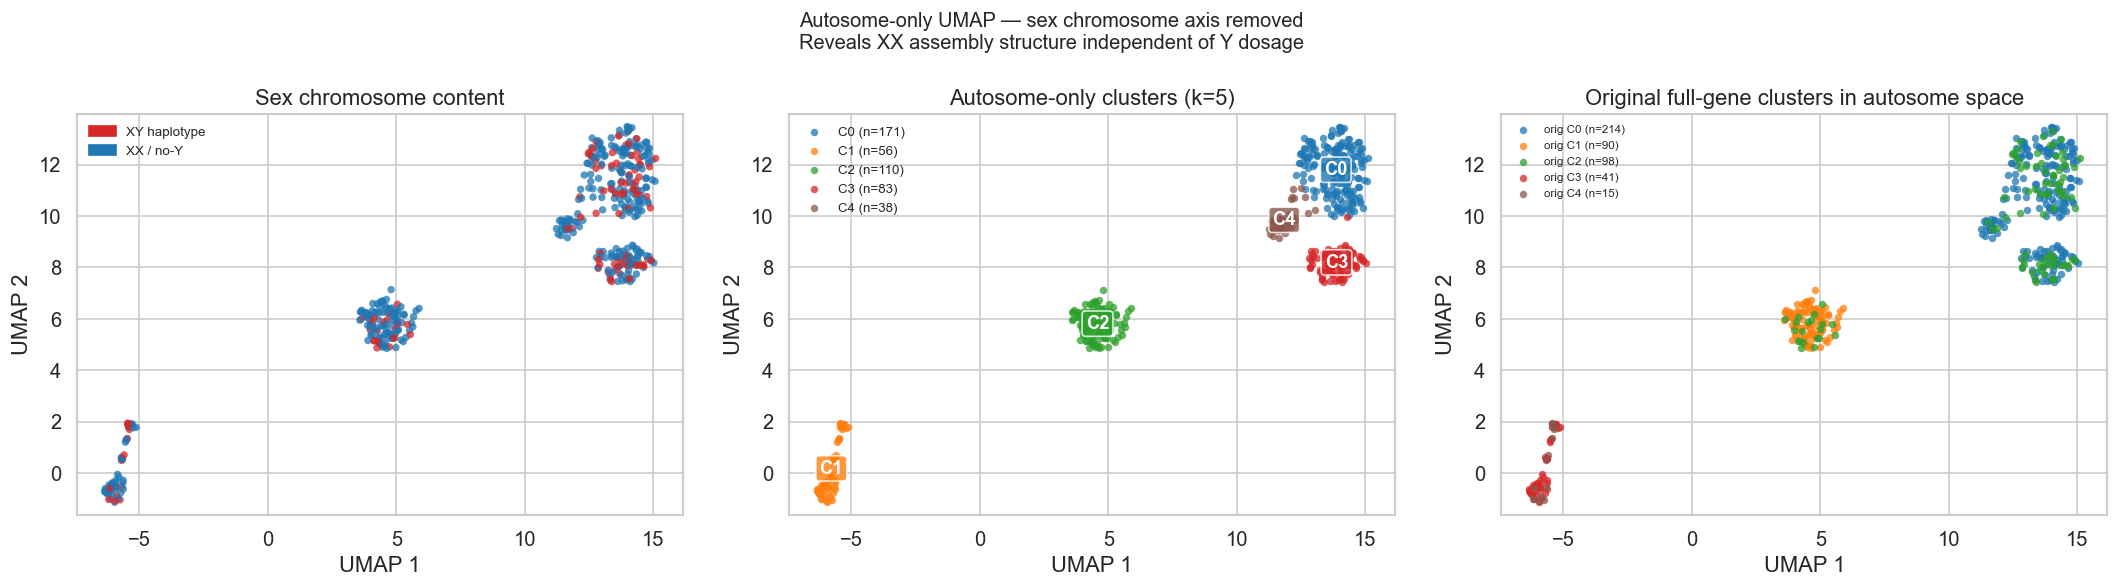


Autosome-only cluster summary:


,n_assemblies,pct_XY
auto_cluster,,
0,171,26.3
1,56,26.8
2,110,18.2
3,83,32.5
4,38,15.8



Original C0 (n=214, XX) → autosome clusters: {0: 126, 3: 56, 4: 32}
Original C1 (n=90, XX) → autosome clusters: {2: 90}
Original C3 (n=41, XX, low-div) → autosome clusters: {1: 41}


: 

In [ ]:
# ── 15c. Autosome-only UMAP ───────────────────────────────────────────────────
# Remove X and Y genes from the pivot before PCA/UMAP.
# Strips the dominant sex chromosome axis, revealing structure among XX assemblies.

_auto_umap_chroms = [str(i) for i in range(1, 23)]
_auto_umap_genes  = s1g[s1g['chrom'].astype(str).isin(_auto_umap_chroms)]['gene_name'].unique()
_auto_in_piv      = [g for g in _auto_umap_genes if g in piv.columns]
print(f'Autosomal genes in pivot: {len(_auto_in_piv):,} / {piv.shape[1]:,} total')

piv_au = piv[_auto_in_piv]

t0 = time.time()
_pca_au = PCA(n_components=50, random_state=42)
_au_pca = _pca_au.fit_transform(piv_au.values)
print(f'PCA (autosome): {_pca_au.explained_variance_ratio_.sum()*100:.1f}% variance  ({time.time()-t0:.1f}s)')

t0 = time.time()
_reducer_au = umap_.UMAP(n_components=2, random_state=42, n_neighbors=20,
                          min_dist=0.2, metric='euclidean')
_au_emb = _reducer_au.fit_transform(_au_pca)
print(f'Autosome UMAP done  ({time.time()-t0:.1f}s)')

au_emb_df = (pd.DataFrame(_au_emb, columns=['UMAP1', 'UMAP2'], index=piv_au.index)
             .reset_index()
             .merge(emb_df[['assembly_accession', 'has_y', 'cluster', 'y_score']],
                    on='assembly_accession', how='left'))

N_CLUST_AU = 5
_km_au = KMeans(n_clusters=N_CLUST_AU, random_state=42, n_init=20)
au_emb_df['auto_cluster'] = _km_au.fit_predict(au_emb_df[['UMAP1', 'UMAP2']])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: XX vs XY
ax = axes[0]
_xy_col_au = au_emb_df['has_y'].map({True: '#d62728', False: '#1f77b4'})
ax.scatter(au_emb_df['UMAP1'], au_emb_df['UMAP2'], c=_xy_col_au, s=20, alpha=0.75, linewidths=0)
ax.legend(handles=[mpatches.Patch(color='#d62728', label='XY haplotype'),
                   mpatches.Patch(color='#1f77b4', label='XX / no-Y')],
          fontsize=8, frameon=False)
ax.set_title('Sex chromosome content'); ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', adjustable='datalim')

# Plot 2: New k-means clusters on autosome UMAP
ax = axes[1]
_pal_au = plt.cm.tab10(np.linspace(0, 0.5, N_CLUST_AU))
for ci in range(N_CLUST_AU):
    sub = au_emb_df[au_emb_df['auto_cluster'] == ci]
    ax.scatter(sub['UMAP1'], sub['UMAP2'], s=20, alpha=0.75,
               color=_pal_au[ci], label=f'C{ci} (n={len(sub)})', linewidths=0)
    cx, cy = sub[['UMAP1', 'UMAP2']].mean()
    ax.text(cx, cy, f'C{ci}', fontsize=11, fontweight='bold', ha='center', va='center',
            color='white', bbox=dict(boxstyle='round,pad=0.2', fc=_pal_au[ci], alpha=0.8))
ax.legend(fontsize=8, frameon=False)
ax.set_title('Autosome-only clusters (k=5)'); ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', adjustable='datalim')

# Plot 3: Original full-gene cluster labels in new space
ax = axes[2]
_pal_orig = plt.cm.tab10(np.linspace(0, 0.5, N_CLUST))
for ci in range(N_CLUST):
    sub = au_emb_df[au_emb_df['cluster'] == ci]
    ax.scatter(sub['UMAP1'], sub['UMAP2'], s=20, alpha=0.75,
               color=_pal_orig[ci], label=f'orig C{ci} (n={len(sub)})', linewidths=0)
ax.legend(fontsize=7, frameon=False)
ax.set_title('Original full-gene clusters in autosome space')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', adjustable='datalim')

plt.suptitle('Autosome-only UMAP — sex chromosome axis removed\n'
             'Reveals XX assembly structure independent of Y dosage', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'assembly_umap_autosome.png', bbox_inches='tight')
plt.show()

# Cluster summary
print('\nAutosome-only cluster summary:')
display(au_emb_df.groupby('auto_cluster').agg(
    n_assemblies=('assembly_accession', 'count'),
    pct_XY=('has_y', lambda x: round(x.mean() * 100, 1)),
))

# How do the original XX-only clusters (C0, C1, C3) distribute in the new space?
print()
for orig_c, label in [(0, 'C0 (n=214, XX)'), (1, 'C1 (n=90, XX)'), (3, 'C3 (n=41, XX, low-div)')]:
    dist = au_emb_df[au_emb_df['cluster'] == orig_c]['auto_cluster'].value_counts().sort_index()
    print(f'Original {label} → autosome clusters: {dist.to_dict()}')


## 16. Gene UMAP — which genes co-vary across assemblies?

Transpose the same matrix: now each **gene** is a point in 462-dimensional assembly space.  
Genes that cluster together tend to be present/absent together — potential linked loci, segmental duplications, or shared structural variants.

Variable genes (var > 0.01): 24,423 / 40,821
Gene PCA: 70.7% variance  (0.1s)
Gene UMAP done  (29.7s)


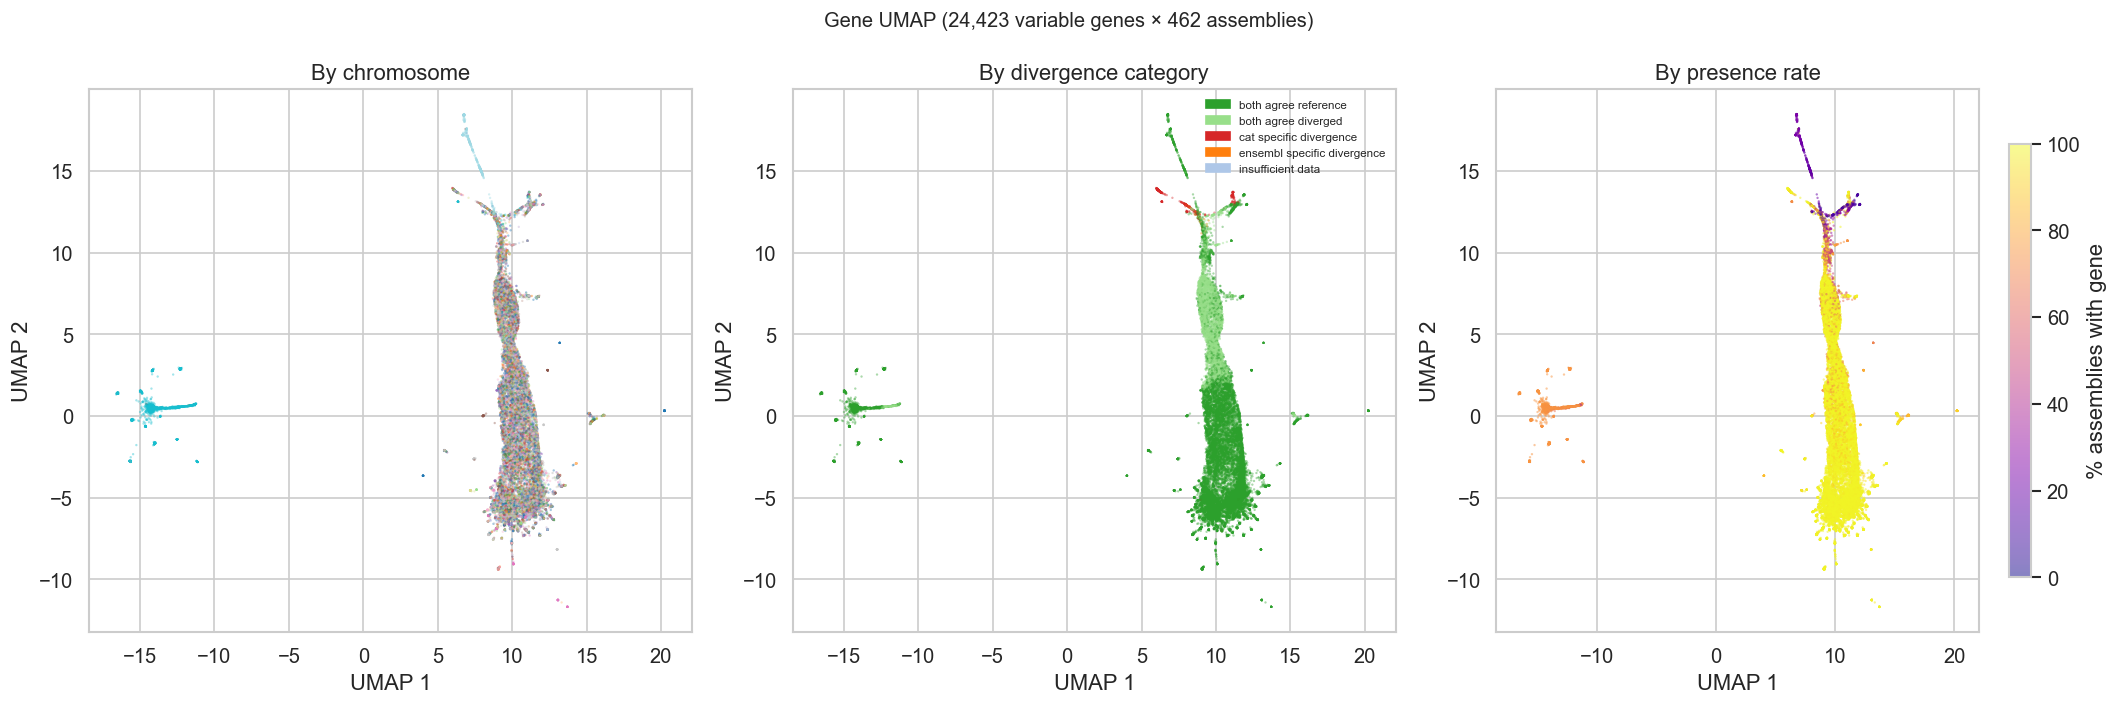

: 

In [ ]:
# Filter to genes with real variance — avoids blowing up UMAP with invariant features
gene_var = piv.var(axis=0)
variable_genes = gene_var[gene_var > 0.01].index
piv_var = piv[variable_genes]
print(f'Variable genes (var > 0.01): {len(variable_genes):,} / {piv.shape[1]:,}')

t0 = time.time()
pca_gene = PCA(n_components=50, random_state=42)
gene_pca = pca_gene.fit_transform(piv_var.T.values)   # genes × assemblies
print(f'Gene PCA: {pca_gene.explained_variance_ratio_.sum()*100:.1f}% variance  ({time.time()-t0:.1f}s)')

t0 = time.time()
reducer_gene = umap_.UMAP(n_components=2, random_state=42, n_neighbors=30,
                           min_dist=0.05, metric='euclidean', low_memory=True)
gene_emb = reducer_gene.fit_transform(gene_pca)
print(f'Gene UMAP done  ({time.time()-t0:.1f}s)')


gene_meta = (s1g[['gene_name','ensembl_biotype','chrom',
                   'predominant_divergence_category','pct_assemblies_both']]
             .drop_duplicates('gene_name'))

gene_emb_df = (pd.DataFrame(gene_emb, columns=['UMAP1','UMAP2'], index=variable_genes)
               .reset_index()
               .merge(gene_meta, on='gene_name', how='left'))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chromosome — cast to str so NaN becomes 'nan' (falls through to default grey)
chrom_palette = plt.cm.tab20(np.linspace(0, 1, len(CHROM_ORDER)))
chrom_to_color = {c: chrom_palette[i] for i, c in enumerate(CHROM_ORDER)}
chrom_colors = [chrom_to_color.get(c, (0.7, 0.7, 0.7, 1))
                for c in gene_emb_df['chrom'].astype(str)]
axes[0].scatter(gene_emb_df['UMAP1'], gene_emb_df['UMAP2'],
                c=chrom_colors, s=2, alpha=0.4, linewidths=0)
axes[0].set_title('By chromosome'); axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')

# Divergence category
div_colors = [DIV_PALETTE.get(str(c), '#aaaaaa')
              for c in gene_emb_df['predominant_divergence_category'].astype(str)]
axes[1].scatter(gene_emb_df['UMAP1'], gene_emb_df['UMAP2'],
                c=div_colors, s=2, alpha=0.4, linewidths=0)
handles = [mpatches.Patch(color=DIV_PALETTE[c], label=c.replace('_', ' ')) for c in DIV_ORDER]
axes[1].legend(handles=handles, fontsize=7, frameon=False)
axes[1].set_title('By divergence category'); axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')

# Presence rate
sc = axes[2].scatter(gene_emb_df['UMAP1'], gene_emb_df['UMAP2'],
                     c=gene_emb_df['pct_assemblies_both'].fillna(0),
                     cmap='plasma', s=2, alpha=0.5, vmin=0, vmax=100, linewidths=0)
plt.colorbar(sc, ax=axes[2], label='% assemblies with gene', shrink=0.8)
axes[2].set_title('By presence rate'); axes[2].set_xlabel('UMAP 1'); axes[2].set_ylabel('UMAP 2')

plt.suptitle(f'Gene UMAP ({len(variable_genes):,} variable genes × 462 assemblies)', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'gene_umap.png', bbox_inches='tight', dpi=150)
plt.show()

## 17. Pangenome: core, soft-core, shell, cloud

Pan-genome terminology applied to gene annotation presence across 462 assemblies.  
Genes at the periphery of the pangenome (low presence) are the most interesting candidates for PAV (presence/absence variation) and population-specific biology.

Gene pan-genome classification:
                    n_genes   pct
pan_class                        
core (≥95%)           34998  85.7
soft-core (80–95%)     1675   4.1
shell (20–80%)         3616   8.9
cloud (<20%)            535   1.3


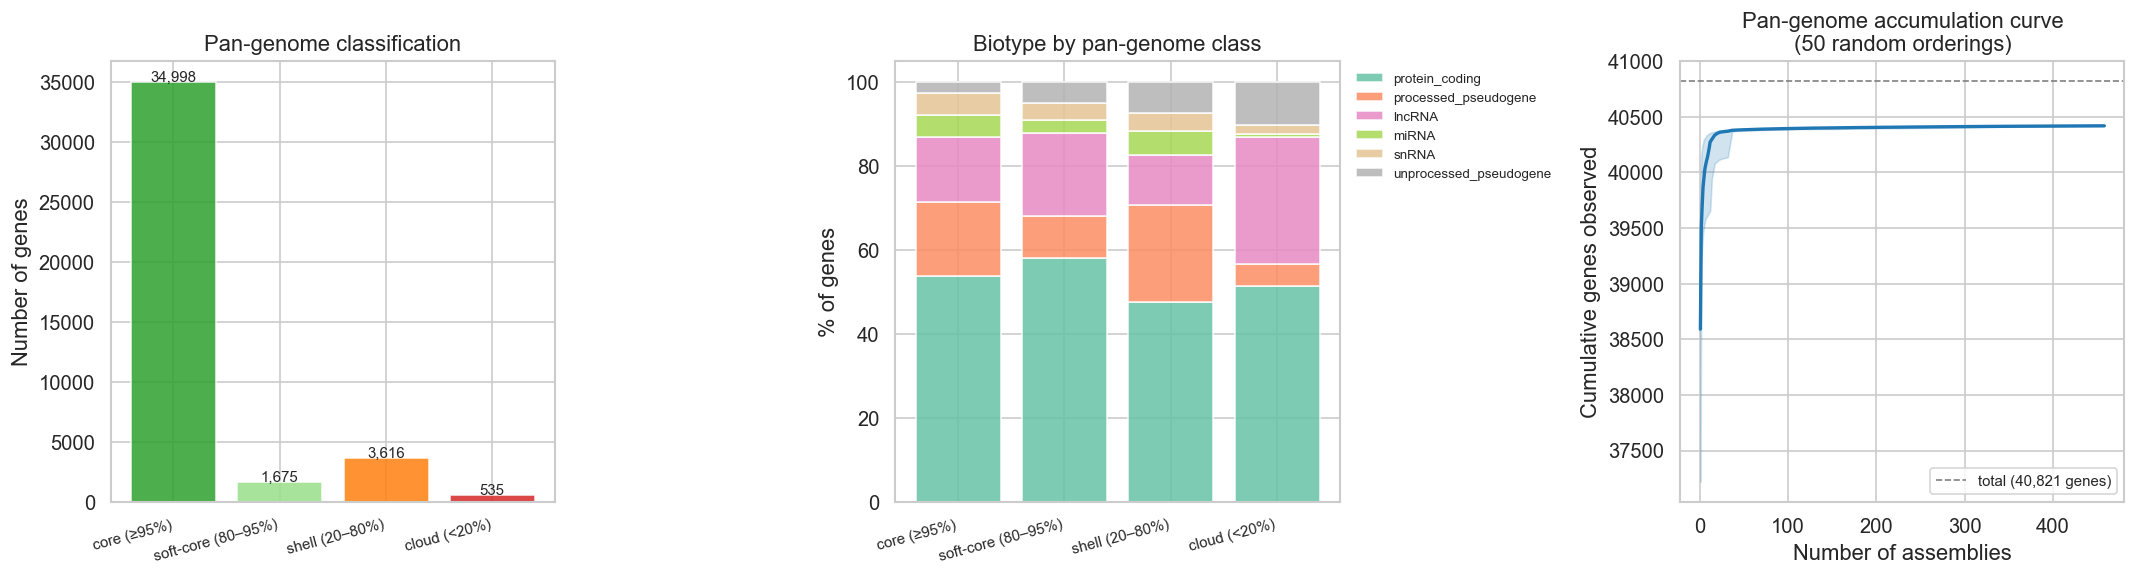

: 

In [ ]:
THRESHOLDS = {'core': 95, 'soft_core': 80, 'shell_lo': 20}

def classify_gene(pct):
    if pct >= THRESHOLDS['core']:      return 'core (≥95%)'
    if pct >= THRESHOLDS['soft_core']: return 'soft-core (80–95%)'
    if pct >= THRESHOLDS['shell_lo']:  return 'shell (20–80%)'
    return 'cloud (<20%)'

s1g['pan_class'] = s1g['pct_assemblies_both'].apply(classify_gene)
pan_order  = ['core (≥95%)', 'soft-core (80–95%)', 'shell (20–80%)', 'cloud (<20%)']
pan_colors = {'core (≥95%)':'#2ca02c','soft-core (80–95%)':'#98df8a',
              'shell (20–80%)':'#ff7f0e','cloud (<20%)':'#d62728'}

counts = s1g['pan_class'].value_counts().reindex(pan_order)
print('Gene pan-genome classification:')
print(counts.to_frame('n_genes').assign(pct=lambda d:(d.n_genes/d.n_genes.sum()*100).round(1)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.bar(range(len(pan_order)), [counts[c] for c in pan_order],
       color=[pan_colors[c] for c in pan_order], alpha=0.85)
ax.set_xticks(range(len(pan_order)))
ax.set_xticklabels(pan_order, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Number of genes')
ax.set_title('Pan-genome classification')
for i, c in enumerate(pan_order):
    ax.text(i, counts[c]+50, f'{counts[c]:,}', ha='center', fontsize=9)

ax = axes[1]
top_bt = s1g['ensembl_biotype'].value_counts().head(6).index
bt_pan = (s1g[s1g['ensembl_biotype'].isin(top_bt)]
          .groupby(['pan_class','ensembl_biotype']).size()
          .unstack(fill_value=0).reindex(pan_order))
bt_pan_pct = bt_pan.div(bt_pan.sum(axis=1), axis=0) * 100
bt_colors = plt.cm.Set2(np.linspace(0, 1, len(top_bt)))
bottom = np.zeros(len(bt_pan_pct))
for bt, col in zip(top_bt, bt_colors):
    vals = bt_pan_pct.get(bt, pd.Series(0, index=bt_pan_pct.index)).values
    ax.bar(range(len(pan_order)), vals, bottom=bottom, color=col, label=bt, alpha=0.85)
    bottom += vals
ax.set_xticks(range(len(pan_order)))
ax.set_xticklabels(pan_order, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('% of genes'); ax.set_title('Biotype by pan-genome class')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)

# ── Fast rarefaction: vectorised cumsum approach ──
ax = axes[2]
presence_bin = (piv != 0).values  # bool array: assemblies × genes
n_assm, n_genes = presence_bin.shape
n_reps = 50
steps = np.unique(np.round(np.geomspace(1, n_assm, 40)).astype(int))

np.random.seed(42)
curves = np.zeros((n_reps, len(steps)), dtype=int)
for r in range(n_reps):
    order = np.random.permutation(n_assm)
    seen = np.zeros(n_genes, dtype=bool)
    for j, k in enumerate(steps):
        seen |= presence_bin[order[:k]].any(axis=0)
        curves[r, j] = seen.sum()

ax.plot(steps, curves.mean(axis=0), color='#1f77b4', lw=2)
ax.fill_between(steps, curves.min(axis=0), curves.max(axis=0), alpha=0.2, color='#1f77b4')
ax.axhline(n_genes, color='grey', ls='--', lw=1, label=f'total ({n_genes:,} genes)')
ax.set_xlabel('Number of assemblies'); ax.set_ylabel('Cumulative genes observed')
ax.set_title('Pan-genome accumulation curve\n(50 random orderings)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'pangenome_classification.png', bbox_inches='tight')
plt.show()

## 18. Gene co-absence: which genes disappear together?

Among flexible genes (present in 20–80% of assemblies), which pairs are co-absent in the same assemblies?  
High co-absence correlation suggests shared structural variation — these genes may sit inside the same SV or segmental duplication.  
Shown as a clustermap of the top most-variable flexible genes.

Shell genes total (20–80%): 3,478
  Autosomal: 1,278
  X-linked:  1,832

Assembly groups:
  XX / no-Y: 345
  XY haplotype: 113


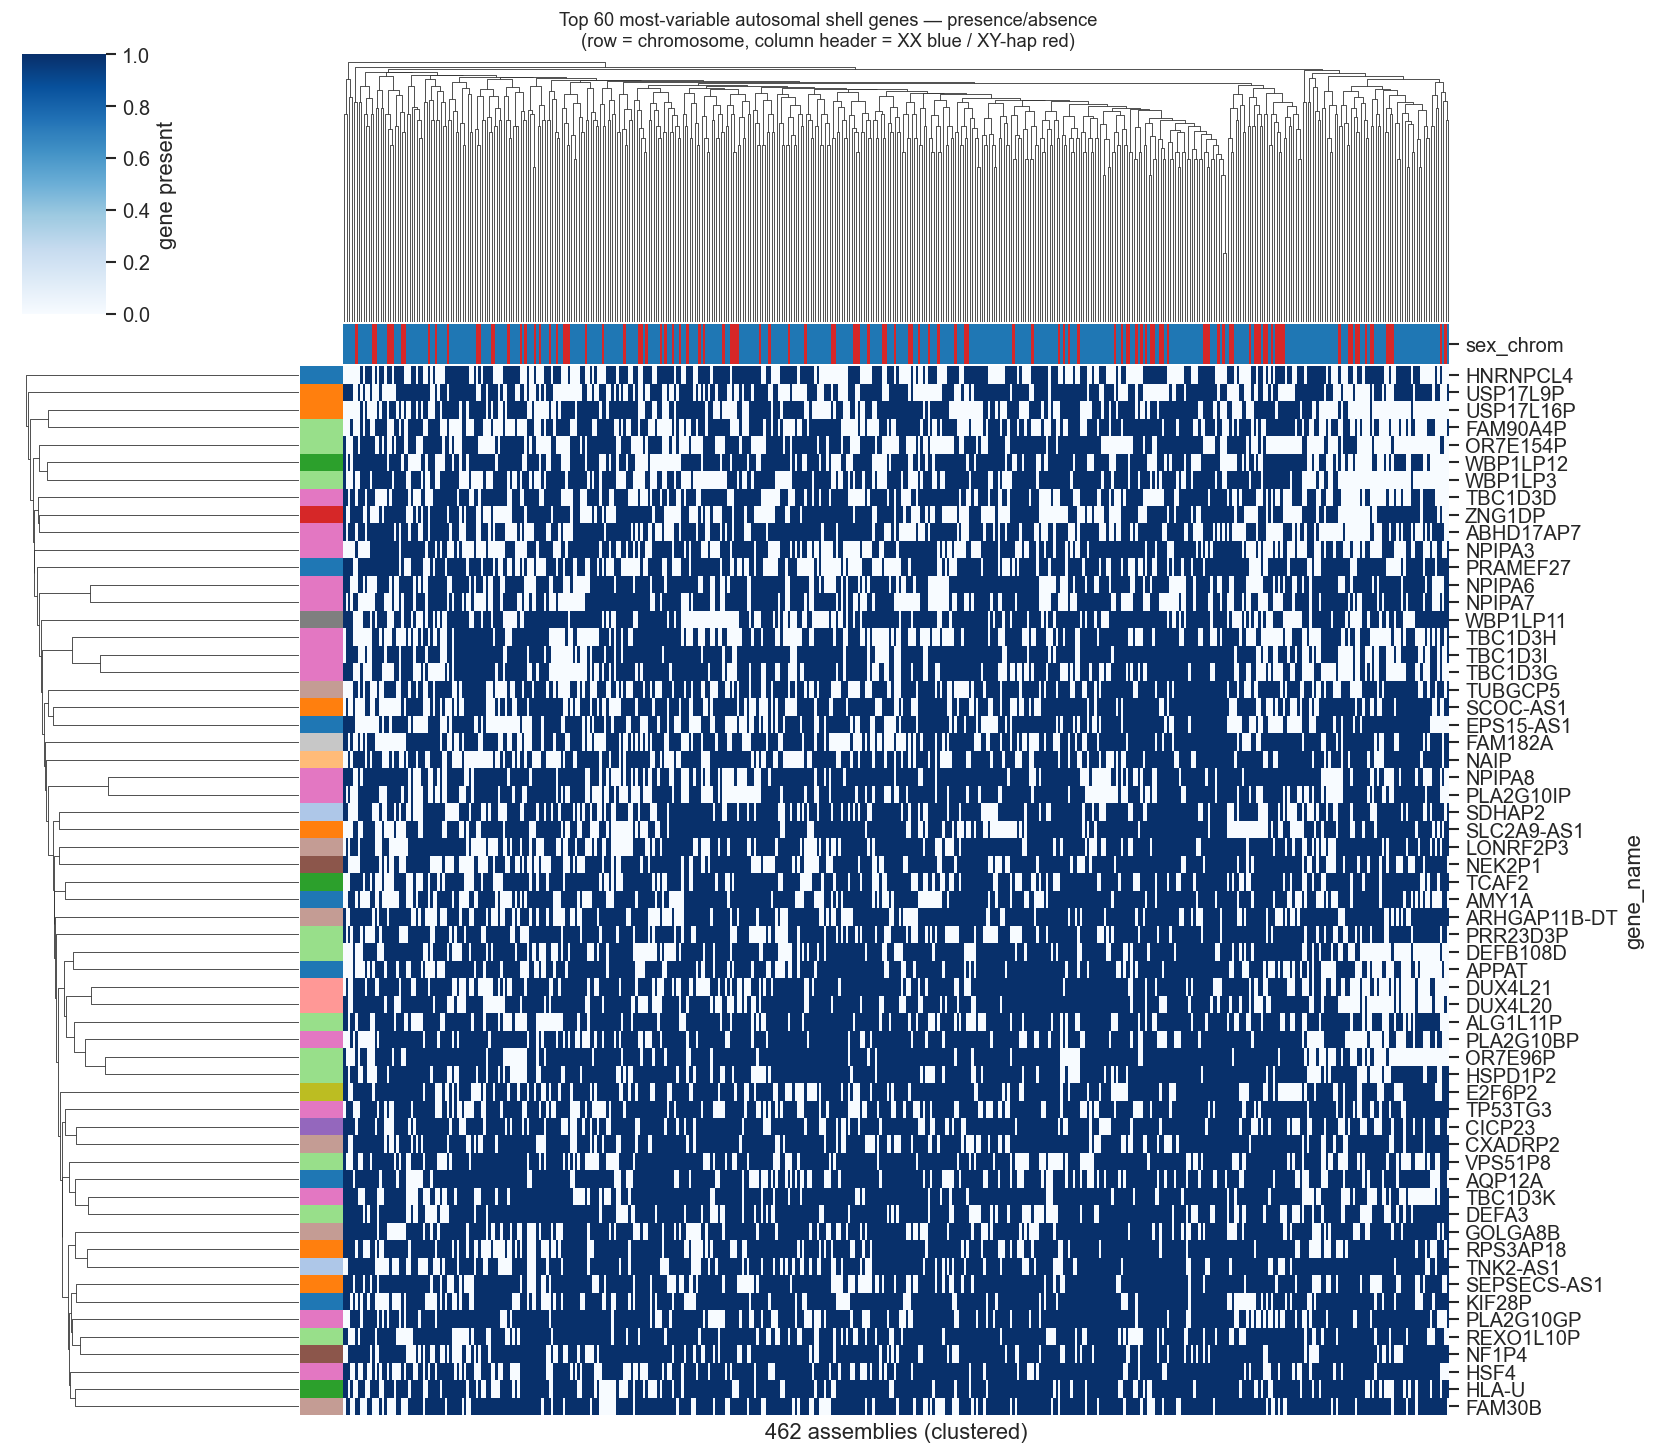

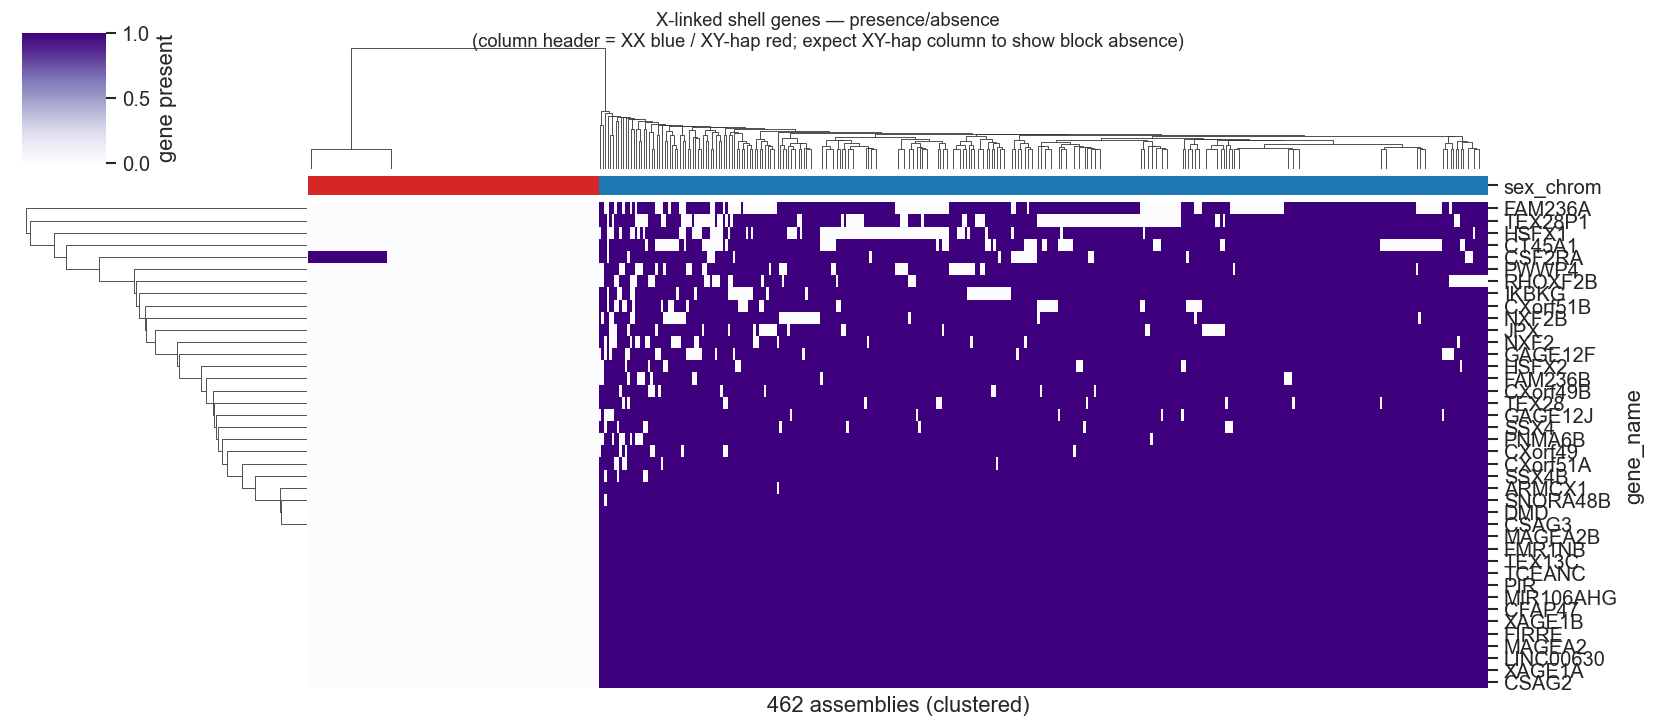


Top 25 co-absent autosomal gene pairs (Jaccard similarity of absence):


,gene_a,gene_b,chrom_a,chrom_b,jaccard
0,ADAM3A,ADAM5,8,8,1.000000
1,5S_rRNA,7SK,6,11,1.000000
2,CA15P2,FAM246B,22,22,0.988506
3,ARPP19P1,BTNL3,5,5,0.950000
4,C4B,CYP21A2,6,6,0.920792
5,CFHR1,CFHR3,1,1,0.913043
6,ALDOA,CDIPT,16,16,0.883333
7,C4B,CYP21A1P,6,6,0.854701
8,DRG1,FAM177A1,22,14,0.839695
9,CD27,DRG1,12,22,0.822055


: 

In [ ]:
import scipy.cluster.hierarchy as _sch
import scipy.spatial.distance as _ssd
import seaborn.matrix as _snm
_snm._no_scipy = False
_snm.hierarchy = _sch
_snm.distance = _ssd

presence_rate = (piv != 0).mean(axis=0) * 100
shell_genes = presence_rate[(presence_rate >= 20) & (presence_rate <= 80)].index

# Autosomal shell genes only — removes X/Y hemizygosity confound
auto_chroms = set([str(i) for i in range(1, 23)])
chrom_for_gene = (s1g[['gene_name','chrom']].drop_duplicates()
                  .assign(chrom=lambda d: d['chrom'].astype(str))
                  .set_index('gene_name')['chrom'])
shell_auto = [g for g in shell_genes if chrom_for_gene.get(g, 'nan') in auto_chroms]
shell_x    = [g for g in shell_genes if chrom_for_gene.get(g, 'nan') == 'X']
print(f'Shell genes total (20–80%): {len(shell_genes):,}')
print(f'  Autosomal: {len(shell_auto):,}')
print(f'  X-linked:  {len(shell_x):,}')

# ── Infer XX vs XY using Y-score from section 15b ──────────────────────────
# has_y is already defined on emb_df; rebuild as a Series indexed by assembly
assm_has_y = emb_df.set_index('assembly_accession')['has_y']
assm_groups = {
    'XX / no-Y': piv.index[piv.index.map(lambda a: not assm_has_y.get(a, False))].tolist(),
    'XY haplotype': piv.index[piv.index.map(lambda a: assm_has_y.get(a, False))].tolist(),
}
print(f'\nAssembly groups:')
for k, v in assm_groups.items():
    print(f'  {k}: {len(v)}')

# ── Clustermap: top 60 most-variable autosomal shell genes ──────────────────
N_TOP = 60
top_auto = piv[shell_auto].var(axis=0).nlargest(N_TOP).index
piv_auto = (piv[top_auto] != 0).astype('float32')

col_chroms = [chrom_for_gene.get(g, 'nan') for g in top_auto]
chrom_pal  = {c: plt.cm.tab20(i / len(CHROM_ORDER)) for i, c in enumerate(CHROM_ORDER)}
col_colors = pd.Series([chrom_pal.get(c, (0.7, 0.7, 0.7, 1)) for c in col_chroms], index=top_auto)

# Row colours for assemblies: XX=blue, XY=red
row_colors_assm = pd.Series(
    [('#d62728' if assm_has_y.get(a, False) else '#1f77b4') for a in piv_auto.index],
    index=piv_auto.index,
    name='sex_chrom'
)

g = sns.clustermap(piv_auto.T, cmap='Blues', figsize=(14, 12),
                   col_cluster=True, row_cluster=True,
                   row_colors=col_colors,
                   col_colors=row_colors_assm,
                   xticklabels=False, yticklabels=True, linewidths=0,
                   cbar_kws={'label': 'gene present'})
g.ax_heatmap.set_xlabel('462 assemblies (clustered)')
g.fig.suptitle(
    f'Top {N_TOP} most-variable autosomal shell genes — presence/absence\n'
    f'(row = chromosome, column header = XX blue / XY-hap red)',
    y=1.01, fontsize=11)
plt.savefig(FIG_DIR / 'coabsence_clustermap_autosome.png', bbox_inches='tight', dpi=150)
plt.show()

# ── X-linked shell genes: show separately to visualise hemizygosity ──────────
if len(shell_x) > 0:
    top_x = piv[shell_x].var(axis=0).nlargest(min(40, len(shell_x))).index
    piv_x = (piv[top_x] != 0).astype('float32')
    g2 = sns.clustermap(piv_x.T, cmap='Purples', figsize=(14, 6),
                        col_cluster=True, row_cluster=True,
                        col_colors=row_colors_assm,
                        xticklabels=False, yticklabels=True, linewidths=0,
                        cbar_kws={'label': 'gene present'})
    g2.ax_heatmap.set_xlabel('462 assemblies (clustered)')
    g2.fig.suptitle(
        f'X-linked shell genes — presence/absence\n'
        f'(column header = XX blue / XY-hap red; expect XY-hap column to show block absence)',
        y=1.01, fontsize=11)
    plt.savefig(FIG_DIR / 'coabsence_clustermap_xchr.png', bbox_inches='tight', dpi=150)
    plt.show()

# ── Vectorised Jaccard on autosomal shell genes ──────────────────────────────
N_JACCARD = min(300, len(shell_auto))
top_auto_j = piv[shell_auto[:N_JACCARD]]
absent = (top_auto_j == 0).values.astype('float32')

inter = absent.T @ absent
total_a = absent.sum(axis=0, keepdims=True)
union = total_a + total_a.T - inter
with np.errstate(invalid='ignore'):
    jaccard = np.where(union > 0, inter / union, 0.0)
np.fill_diagonal(jaccard, 0)

gene_list = top_auto_j.columns.tolist()
rows, cols = np.unravel_index(np.argsort(jaccard.ravel())[::-1], jaccard.shape)
seen = set()
top_pairs = []
for r, c in zip(rows, cols):
    if r >= c: continue
    if (r, c) in seen: continue
    seen.add((r, c))
    top_pairs.append({'gene_a': gene_list[r], 'gene_b': gene_list[c], 'jaccard': jaccard[r, c]})
    if len(top_pairs) == 25: break

pairs_df = (pd.DataFrame(top_pairs)
    .merge(s1g[['gene_name','chrom']].drop_duplicates().rename(
           columns={'gene_name':'gene_a','chrom':'chrom_a'}), on='gene_a', how='left')
    .merge(s1g[['gene_name','chrom']].drop_duplicates().rename(
           columns={'gene_name':'gene_b','chrom':'chrom_b'}), on='gene_b', how='left'))

print('\nTop 25 co-absent autosomal gene pairs (Jaccard similarity of absence):')
display(pairs_df[['gene_a','gene_b','chrom_a','chrom_b','jaccard']].reset_index(drop=True))